# Alura Store

### Bibliotecas


In [183]:
# Importando bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display


### Importação dos dados

In [184]:
# Definindo origem dos dados 
url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

# Lendo arquivos de dados 
loja1 = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

### Funções e Variáveis Auxiliares

In [185]:
# Variáveis auxiliares

# Lojas
loja = "Loja 1"
df_loja = loja1

# Colunas Categóricas - Exceto Data da Compra - Com avaliação da Compra
colunas_categoricas = ["Produto", "Categoria do Produto", "Vendedor", "Local da compra", "Tipo de pagamento", "Avaliação da compra"]

# Colunas Numéricas - Exceto lat, lon e Avaliação da Compra
colunas_numéricas = ["Preço", "Frete", "Quantidade de parcelas"]

In [186]:
# Conhecendo os dados e estruturas 
def conhecendo_dados(df, nome_loja):
    print(f"=== {nome_loja} ===")
    display(df.shape)
    display(df.head())


In [187]:
# Exibe estatística descritivas de colunas numéricas e categóricas da loja 
def estatisticas_loja(df, nome_loja):
    print(f"\n {nome_loja} - Colunas Numéricas ")
    display(df.describe())
    
    print(f"\n {nome_loja} - Colunas Categóricas ")
    display(df.describe(include='object'))

In [188]:
# Gera gráfico de barras da distribuição de coluna categórica
def grafico_distribuicao(df, coluna, nome_loja, rotacionar_labels=True):
    contagem = df[coluna].value_counts()
    
    plt.figure(figsize=(8,5))
    barras = plt.bar(contagem.index, contagem.values)  
    
    # Adiciona a quantidade no topo de cada barra
    for barra in barras:
        altura = barra.get_height()
        plt.text(barra.get_x() + barra.get_width()/2, altura + 0.1, int(altura),
                 ha='center', va='bottom')

    plt.title(f"Distribuição de {coluna} - {nome_loja}")
    plt.ylabel("Contagem")
    plt.xlabel(coluna)
    
    # Rotação opcional dos labels
    if rotacionar_labels:
        plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

In [189]:
# Gera histograma para coluna numérica
def grafico_histograma_numerico(df, coluna, nome_loja, bins=10):
    plt.figure(figsize=(8,5))
    plt.hist(df[coluna], bins=bins, edgecolor='black')
    plt.title(f"Distribuição de {coluna} dos Produtos - {nome_loja}")
    plt.xlabel(coluna)
    plt.ylabel("Contagem")
    plt.tight_layout()
    plt.show()

In [190]:
# Gera boxplot para colunas numéricas
def grafico_boxplot_numerico(df, coluna, nome_loja):
    
    plt.figure(figsize=(10,4))

    plt.boxplot(df[coluna], widths=0.5, vert=False, patch_artist=True)

    plt.title(f"Distribuição de {coluna} dos Produtos - {nome_loja}")
    plt.xlabel(coluna)

    plt.show()

In [191]:
# Gera gráfico de barras para Top N categorias/valores mais ou menos vendidos
def grafico_top_categorias(df, coluna, nome_loja, n=10, mais_frequentes=True, rotacionar_labels=True):
    contagem = df[coluna].value_counts()
    
    if mais_frequentes:
        top = contagem.head(n)
        titulo = f"Top {n} {coluna}s Mais Vendidos - {nome_loja}"
    else:
        top = contagem.tail(n)
        titulo = f"Top {n} {coluna}s Menos Vendidos - {nome_loja}"
    
    plt.figure(figsize=(8,5))
    top.plot(kind='bar')
    plt.title(titulo)
    plt.xlabel(coluna)
    plt.ylabel("Vendas")
    
    # Rotação opcional dos labels
    if rotacionar_labels:
        plt.xticks(rotation=60, ha='right')
    plt.tight_layout()
    plt.show()

### Análise Exploratória

#### Loja 1 

##### Conhecendo os dados

In [192]:
conhecendo_dados(df_loja, loja)

=== Loja 1 ===


(2359, 12)

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


##### Qualidade dos Dados

Os dados foram disponibilizados sem valores nulos, sem duplicidade, sem valores negativos ou zerados

In [193]:
# Verificar tipos, estrutura e se há nulos
df_loja.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Produto                 2359 non-null   object 
 1   Categoria do Produto    2359 non-null   object 
 2   Preço                   2359 non-null   float64
 3   Frete                   2359 non-null   float64
 4   Data da Compra          2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Local da compra         2359 non-null   object 
 7   Avaliação da compra     2359 non-null   int64  
 8   Tipo de pagamento       2359 non-null   object 
 9   Quantidade de parcelas  2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB


In [194]:
# Validação se há alguma data incorreta - Considerando que o campo esta como object 
datas_convertidas = pd.to_datetime(df_loja["Data da Compra"], dayfirst=True, errors="coerce")
quantidade_invalidas = datas_convertidas.isna().sum()

print(f"Data da Compra: {quantidade_invalidas} valores incorretos")

Data da Compra: 0 valores incorretos


##### Explorando os Dados

In [195]:
# Estatísticas decritivas das vendas
estatisticas_loja(df_loja, loja)


 Loja 1 - Colunas Numéricas 


,Preço,Frete,Avaliação da compra,Quantidade de parcelas,lat,lon
count,2359.000000,2359.000000,2359.000000,2359.000000,2359.000000,2359.000000
mean,650.491361,34.691805,3.976685,2.943196,-20.763366,-47.349385
std,819.582778,43.814183,1.415370,2.819897,5.372400,4.183180
min,10.070000,0.000000,1.000000,1.000000,-30.170000,-70.550000
25%,74.345000,4.141783,3.000000,1.000000,-22.250000,-48.790000
50%,313.750000,16.498835,5.000000,1.000000,-22.190000,-48.790000
75%,904.130000,48.050074,5.000000,4.000000,-18.100000,-44.380000
max,3969.380000,214.377060,5.000000,24.000000,1.410000,-36.590000



 Loja 1 - Colunas Categóricas 


,Produto,Categoria do Produto,Data da Compra,Vendedor,Local da compra,Tipo de pagamento
count,2359,2359,2359,2359,2359,2359
unique,51,8,1018,14,26,4
top,Micro-ondas,moveis,15/05/2021,Thiago Silva,SP,cartao_credito
freq,60,465,7,197,984,1704


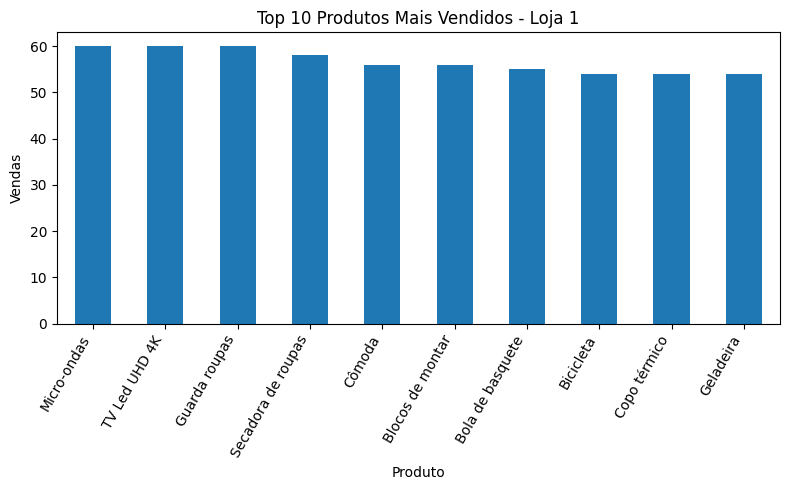

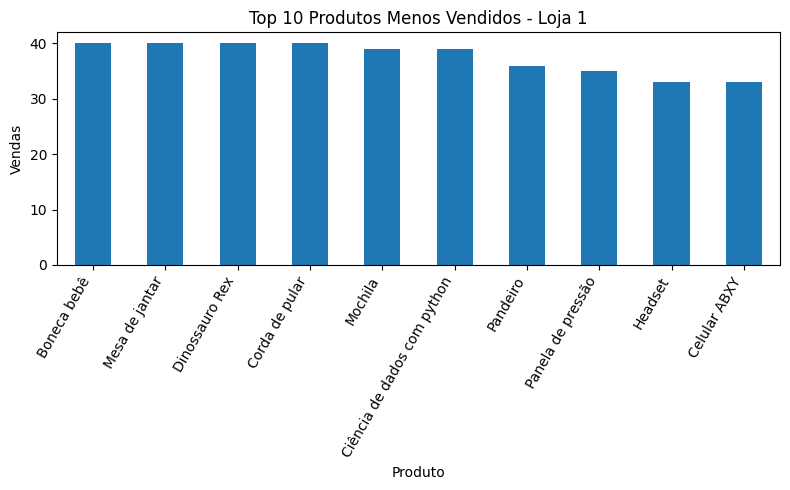

In [196]:
# Top 10 produtos mais vendidos e menos vendidos
grafico_top_categorias(df_loja, "Produto", loja, 10)
grafico_top_categorias(df_loja, "Produto", loja, 10, False)

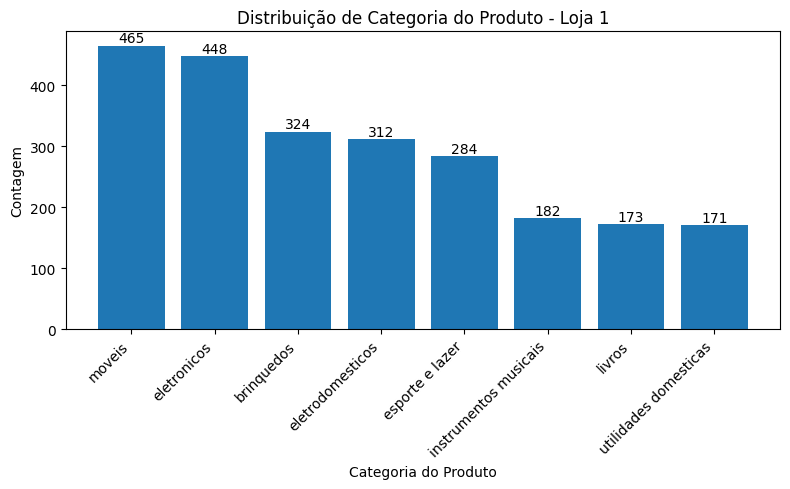

In [197]:
# Distribuição das Categorias do Produto 
grafico_distribuicao(df_loja,"Categoria do Produto", loja)

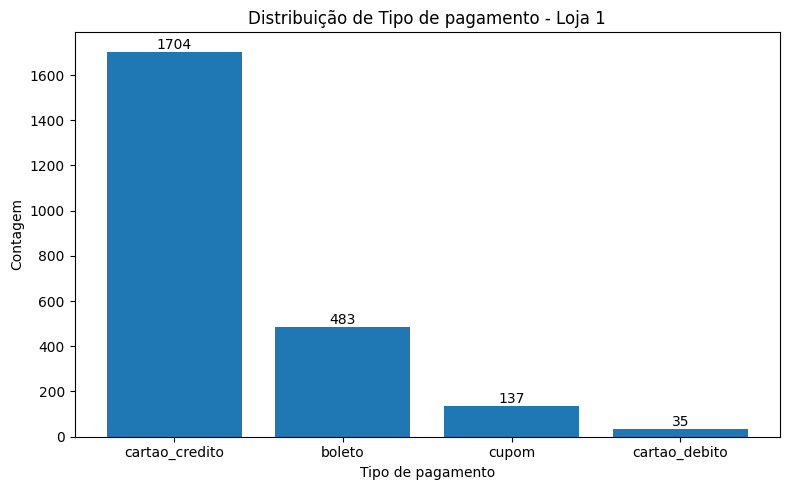

In [198]:
# Distribuição dos Tipos de Pagamento
grafico_distribuicao(df_loja,"Tipo de pagamento", loja, False)

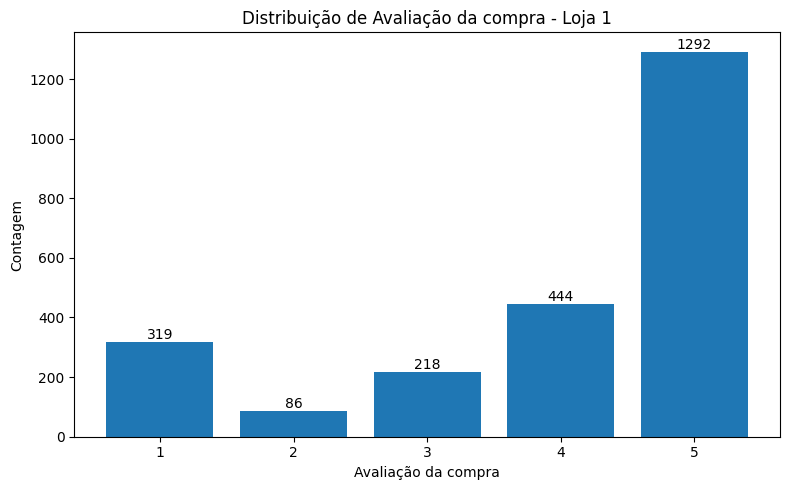

In [199]:
# Distribuição das Avaliações de Compra
grafico_distribuicao(df_loja, "Avaliação da compra", loja, False)

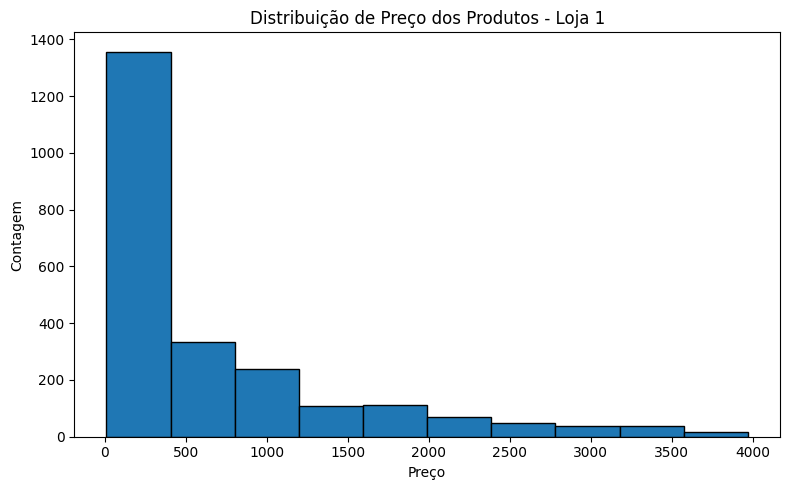

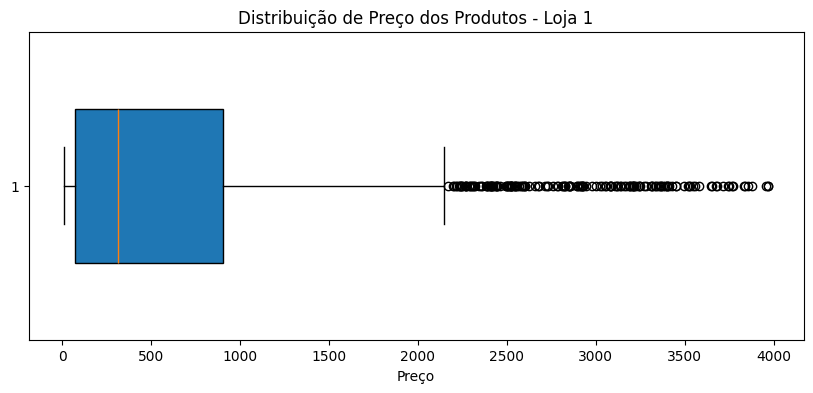

In [200]:
# Distribuição dos Preços dos Produtos 
grafico_histograma_numerico(df_loja, "Preço", loja, 10)
grafico_boxplot_numerico(df_loja, "Preço", loja)

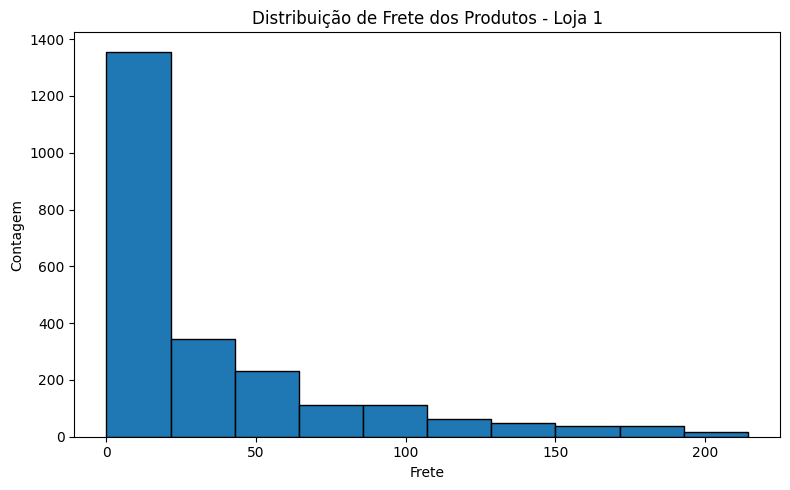

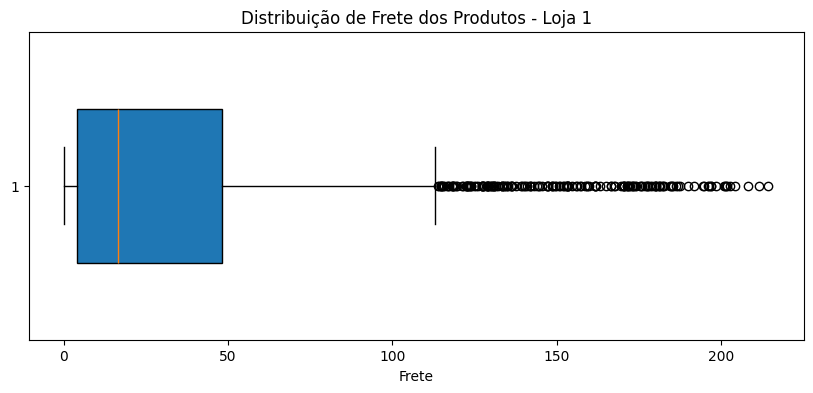

In [201]:
# Distribuição do Frete dos Produtos
grafico_histograma_numerico(df_loja, "Frete", loja, 10)
grafico_boxplot_numerico(df_loja, "Frete", loja)

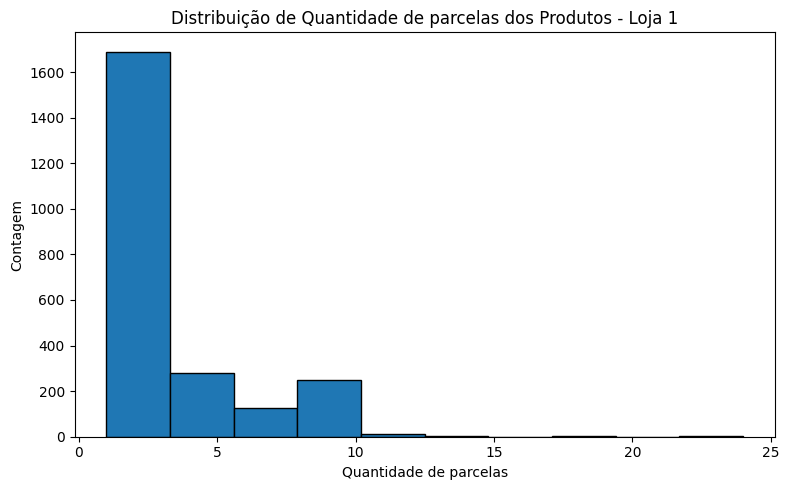

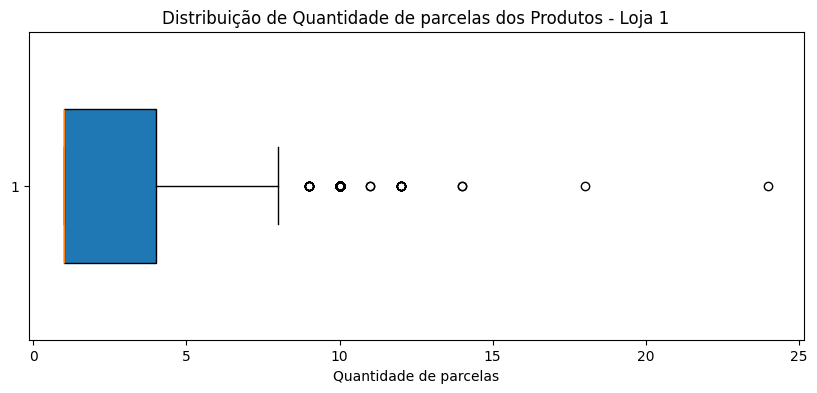

In [202]:
# Distribuição da Quantidade de parcelas dos Produtos
grafico_histograma_numerico(df_loja, "Quantidade de parcelas", loja, 10)
grafico_boxplot_numerico(df_loja, "Quantidade de parcelas", loja)

#### Loja 2

In [203]:
# Atualizar loja
loja = "Loja 2"
df_loja = loja2

##### Conhecendo os dados

In [204]:
conhecendo_dados(df_loja, loja)

=== Loja 2 ===


(2359, 12)

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Cadeira de escritório,moveis,378.20,20.421138,04/08/2021,Thiago Silva,MG,1,boleto,1,-18.10,-44.38
1,Pandeiro,instrumentos musicais,102.37,3.035334,26/11/2020,Bianca Santos,RJ,3,cartao_credito,4,-22.25,-42.66
2,Cama king,moveis,591.13,31.759020,22/10/2021,Thiago Silva,SC,5,cartao_credito,10,-27.45,-50.95
3,Cama king,moveis,1208.24,61.919584,04/05/2022,Larissa Alves,RS,5,cartao_credito,10,-30.17,-53.50
4,Cadeira de escritório,moveis,530.41,25.827176,26/02/2022,Lucas Oliveira,SP,4,cartao_credito,3,-22.19,-48.79


##### Qualidade dos Dados

Os dados foram disponibilizados sem valores nulos, sem duplicidade, sem valores negativos ou zerados

In [205]:
# Verificar tipos, estrutura e se há nulos
df_loja.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Produto                 2359 non-null   object 
 1   Categoria do Produto    2359 non-null   object 
 2   Preço                   2359 non-null   float64
 3   Frete                   2359 non-null   float64
 4   Data da Compra          2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Local da compra         2359 non-null   object 
 7   Avaliação da compra     2359 non-null   int64  
 8   Tipo de pagamento       2359 non-null   object 
 9   Quantidade de parcelas  2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB


In [206]:
# Validação se há alguma data incorreta - Considerando que o campo esta como object 
datas_convertidas = pd.to_datetime(df_loja["Data da Compra"], dayfirst=True, errors="coerce")
quantidade_invalidas = datas_convertidas.isna().sum()

print(f"Data da Compra: {quantidade_invalidas} valores incorretos")

Data da Compra: 0 valores incorretos


##### Explorando os Dados

In [207]:
# Estatísticas decritivas das vendas
estatisticas_loja(df_loja, loja)


 Loja 2 - Colunas Numéricas 


,Preço,Frete,Avaliação da compra,Quantidade de parcelas,lat,lon
count,2359.000000,2359.000000,2359.000000,2359.000000,2359.000000,2359.000000
mean,630.970352,33.621941,4.037304,2.902501,-20.473243,-47.098508
std,794.078997,42.321932,1.356153,2.848416,5.321015,4.169111
min,10.160000,0.000000,1.000000,1.000000,-30.170000,-70.550000
25%,72.730000,3.904020,4.000000,1.000000,-22.250000,-48.790000
50%,290.960000,15.406740,5.000000,1.000000,-22.190000,-48.790000
75%,903.580000,47.250196,5.000000,4.000000,-18.100000,-44.380000
max,3937.850000,216.707633,5.000000,24.000000,1.990000,-36.590000



 Loja 2 - Colunas Categóricas 


,Produto,Categoria do Produto,Data da Compra,Vendedor,Local da compra,Tipo de pagamento
count,2359,2359,2359,2359,2359,2359
unique,51,8,1025,14,26,4
top,Iniciando em programação,moveis,20/12/2021,Thiago Silva,SP,cartao_credito
freq,65,442,7,195,985,1721


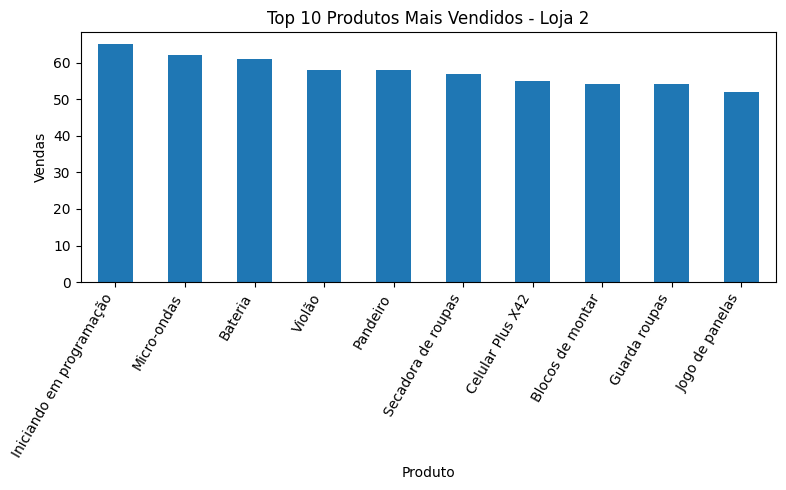

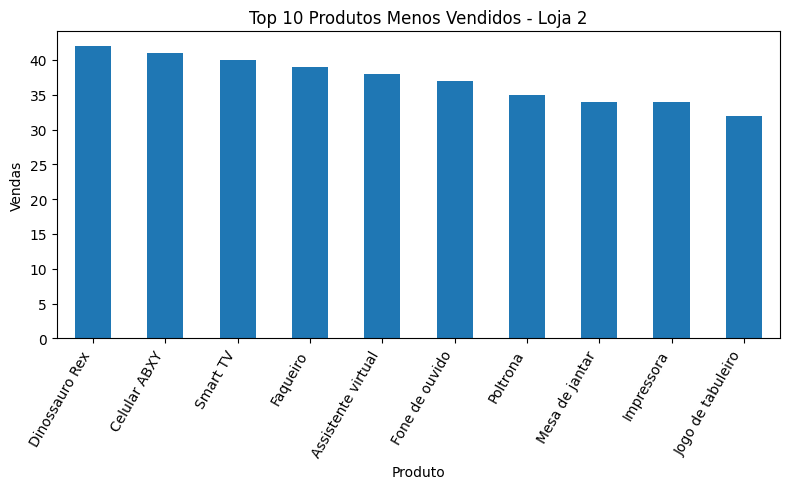

In [208]:
# Top 10 produtos mais vendidos e menos vendidos
grafico_top_categorias(df_loja, "Produto", loja, 10)
grafico_top_categorias(df_loja, "Produto", loja, 10, False)

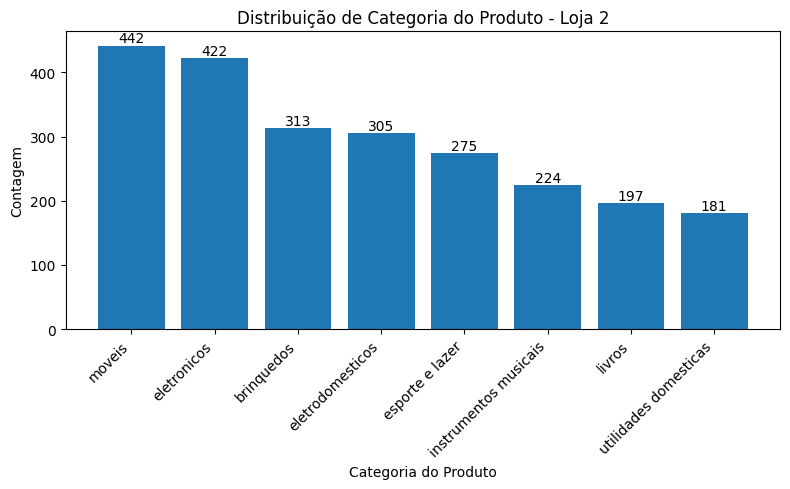

In [209]:
# Distribuição das Categorias do Produto 
grafico_distribuicao(df_loja,"Categoria do Produto", loja)

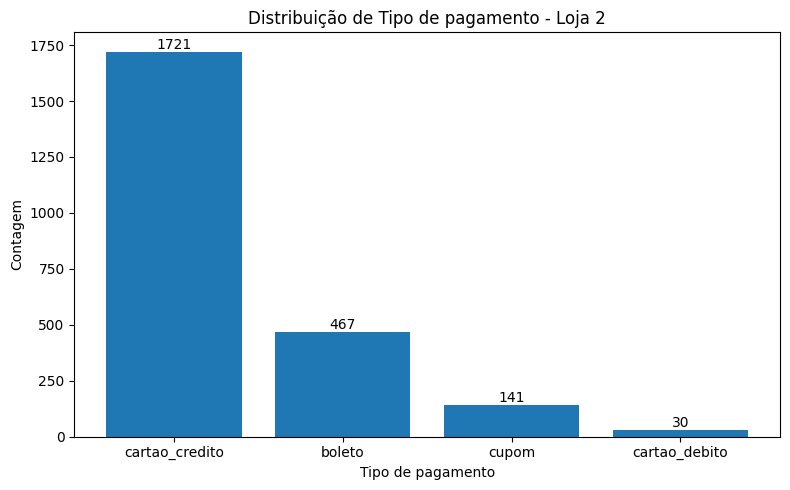

In [210]:
# Distribuição dos Tipos de Pagamento
grafico_distribuicao(df_loja,"Tipo de pagamento", loja, False)

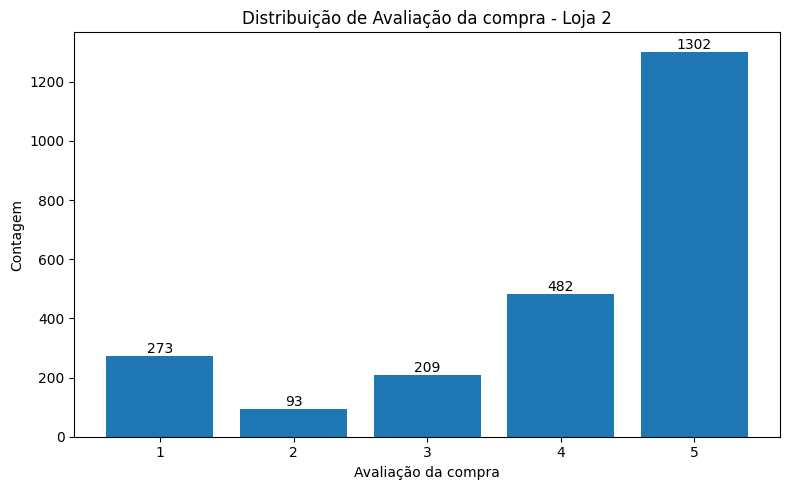

In [211]:
# Distribuição das Avaliações de Compra
grafico_distribuicao(df_loja, "Avaliação da compra", loja, False)

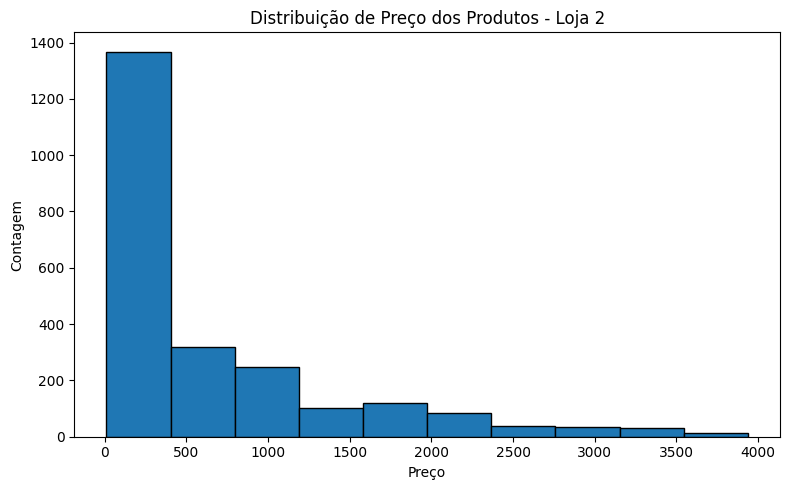

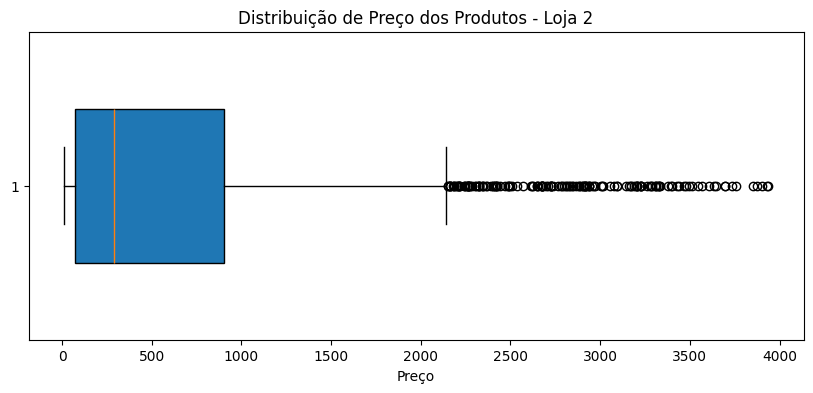

In [212]:
# Distribuição dos Preços dos Produtos 
grafico_histograma_numerico(df_loja, "Preço", loja, 10)
grafico_boxplot_numerico(df_loja, "Preço", loja)

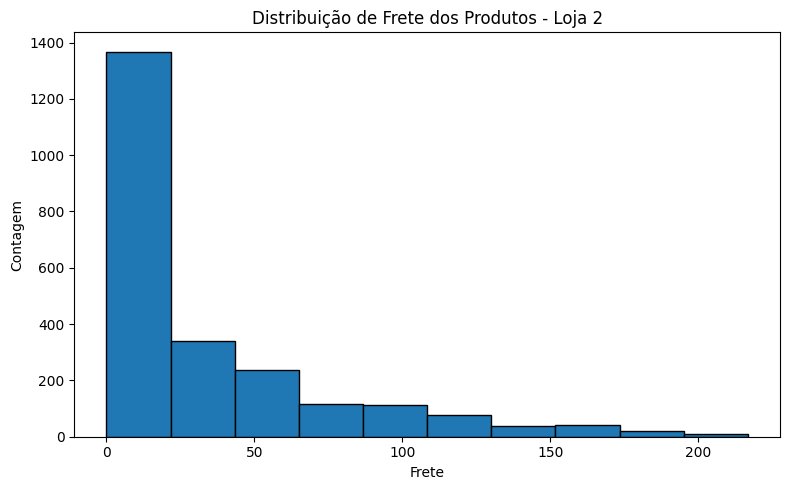

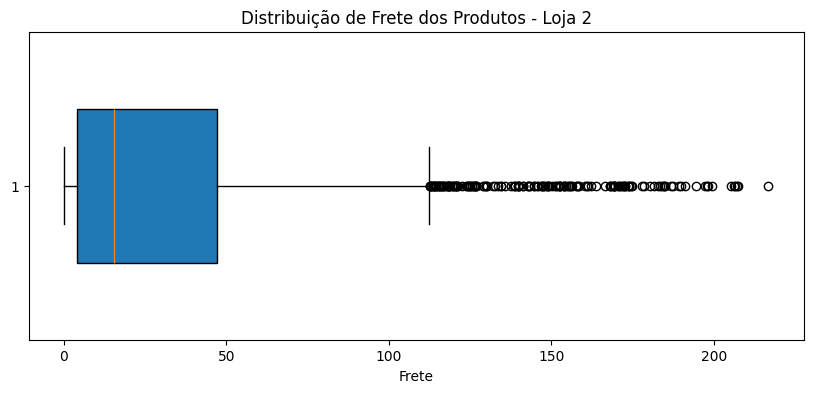

In [213]:
# Distribuição do Frete dos Produtos
grafico_histograma_numerico(df_loja, "Frete", loja, 10)
grafico_boxplot_numerico(df_loja, "Frete", loja)

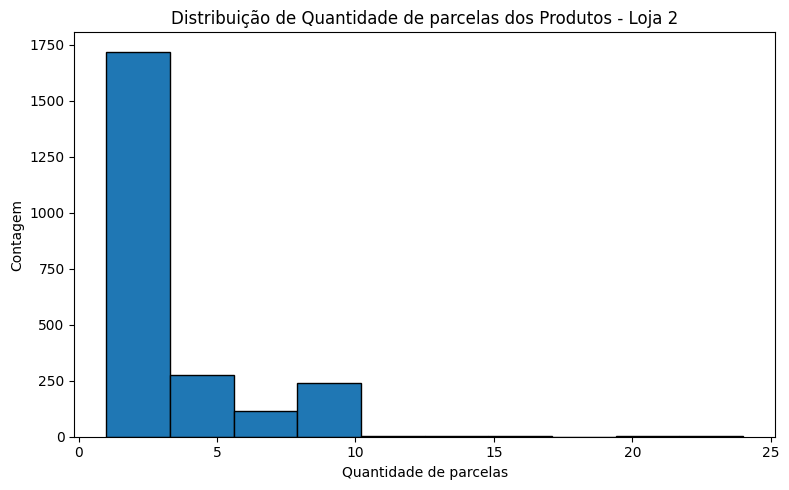

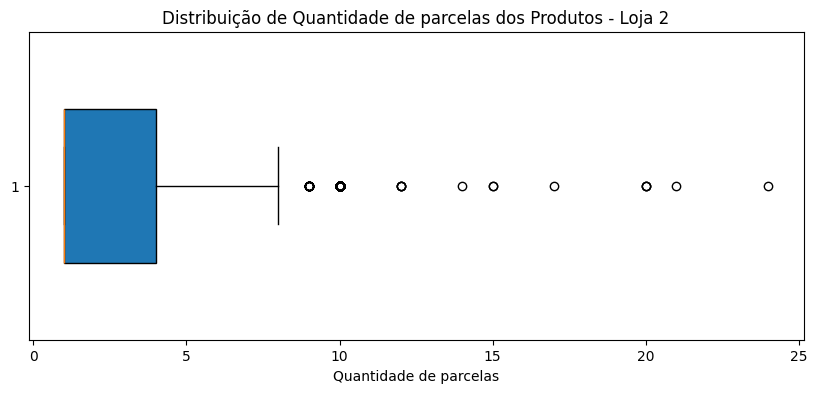

In [214]:
# Distribuição da Quantidade de parcelas dos Produtos
grafico_histograma_numerico(df_loja, "Quantidade de parcelas", loja, 10)
grafico_boxplot_numerico(df_loja, "Quantidade de parcelas", loja)

#### Loja 3

In [215]:
# Atualizar loja
loja = "Loja 3"
df_loja = loja3

##### Conhecendo os dados

In [216]:
conhecendo_dados(df_loja, loja)

=== Loja 3 ===


(2359, 12)

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Secadora de roupas,eletrodomesticos,1713.50,88.823159,17/12/2021,Camila Ribeiro,CE,4,cartao_credito,4,-5.20,-39.53
1,Cômoda,moveis,386.81,18.180908,10/02/2021,Larissa Alves,RS,3,cartao_credito,1,-30.17,-53.50
2,Violão,instrumentos musicais,404.62,23.197592,22/01/2023,Lucas Oliveira,SP,5,cartao_credito,3,-22.19,-48.79
3,Bola de vôlei,esporte e lazer,78.40,4.463341,22/03/2022,Pedro Gomes,BA,4,cartao_credito,6,-13.29,-41.71
4,Guarda roupas,moveis,694.76,34.578319,12/01/2022,Bianca Santos,SP,1,cartao_credito,1,-22.19,-48.79


##### Qualidade dos Dados

Os dados foram disponibilizados sem valores nulos, sem duplicidade, sem valores negativos ou zerados

In [217]:
# Verificar tipos, estrutura e se há nulos
df_loja.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Produto                 2359 non-null   object 
 1   Categoria do Produto    2359 non-null   object 
 2   Preço                   2359 non-null   float64
 3   Frete                   2359 non-null   float64
 4   Data da Compra          2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Local da compra         2359 non-null   object 
 7   Avaliação da compra     2359 non-null   int64  
 8   Tipo de pagamento       2359 non-null   object 
 9   Quantidade de parcelas  2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB


In [218]:
# Validação se há alguma data incorreta - Considerando que o campo esta como object 
datas_convertidas = pd.to_datetime(df_loja["Data da Compra"], dayfirst=True, errors="coerce")
quantidade_invalidas = datas_convertidas.isna().sum()

print(f"Data da Compra: {quantidade_invalidas} valores incorretos")

Data da Compra: 0 valores incorretos


##### Explorando os Dados

In [219]:
# Estatísticas decritivas das vendas
estatisticas_loja(df_loja, loja)


 Loja 3 - Colunas Numéricas 


,Preço,Frete,Avaliação da compra,Quantidade de parcelas,lat,lon
count,2359.000000,2359.000000,2359.000000,2359.000000,2359.000000,2359.000000
mean,620.612560,33.074464,4.048326,2.967783,-20.405396,-47.129233
std,774.191691,41.260516,1.386426,2.812153,5.465572,4.197520
min,10.080000,0.000000,1.000000,1.000000,-30.170000,-70.550000
25%,76.560000,4.149261,4.000000,1.000000,-22.250000,-48.790000
50%,301.670000,15.879702,5.000000,2.000000,-22.190000,-48.790000
75%,888.040000,46.635503,5.000000,4.000000,-18.100000,-44.380000
max,3957.620000,211.257624,5.000000,24.000000,1.990000,-36.590000



 Loja 3 - Colunas Categóricas 


,Produto,Categoria do Produto,Data da Compra,Vendedor,Local da compra,Tipo de pagamento
count,2359,2359,2359,2359,2359,2359
unique,51,8,1024,14,27,4
top,Kit banquetas,moveis,01/08/2022,Larissa Alves,SP,cartao_credito
freq,57,499,8,186,983,1753


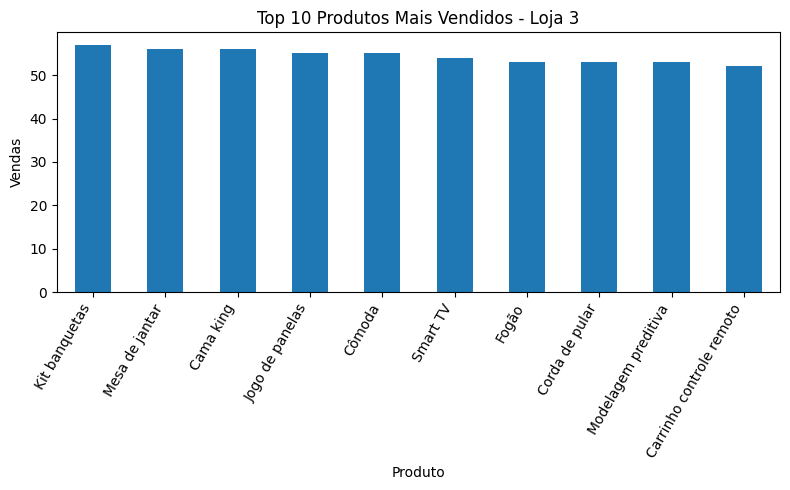

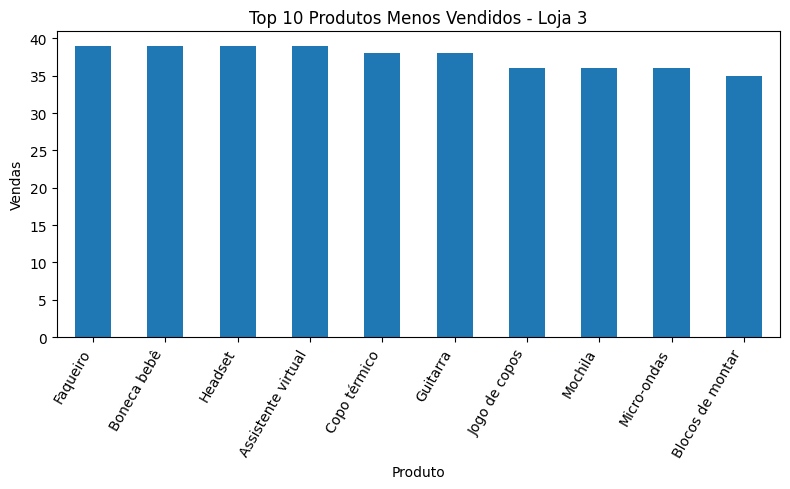

In [220]:
# Top 10 produtos mais vendidos e menos vendidos
grafico_top_categorias(df_loja, "Produto", loja, 10)
grafico_top_categorias(df_loja, "Produto", loja, 10, False)

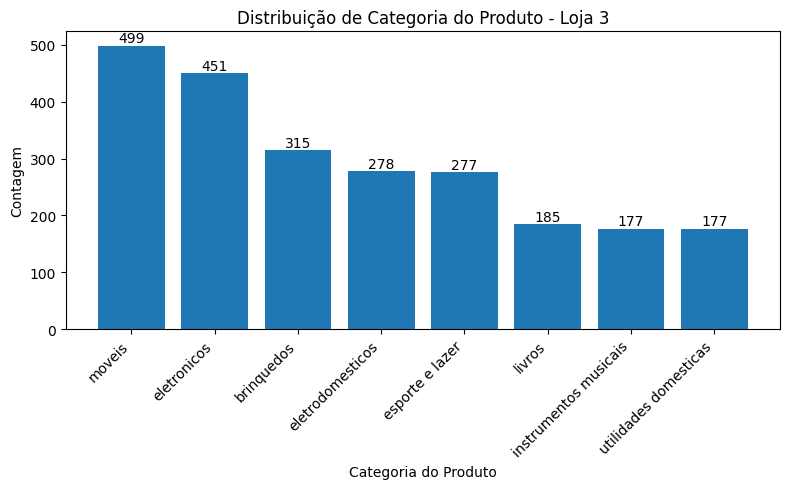

In [221]:
# Distribuição das Categorias do Produto 
grafico_distribuicao(df_loja,"Categoria do Produto", loja)

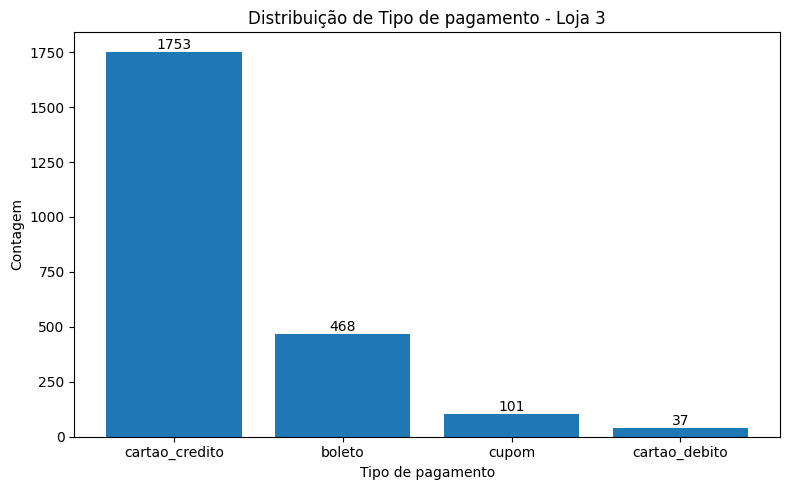

In [222]:
# Distribuição dos Tipos de Pagamento
grafico_distribuicao(df_loja,"Tipo de pagamento", loja, False)

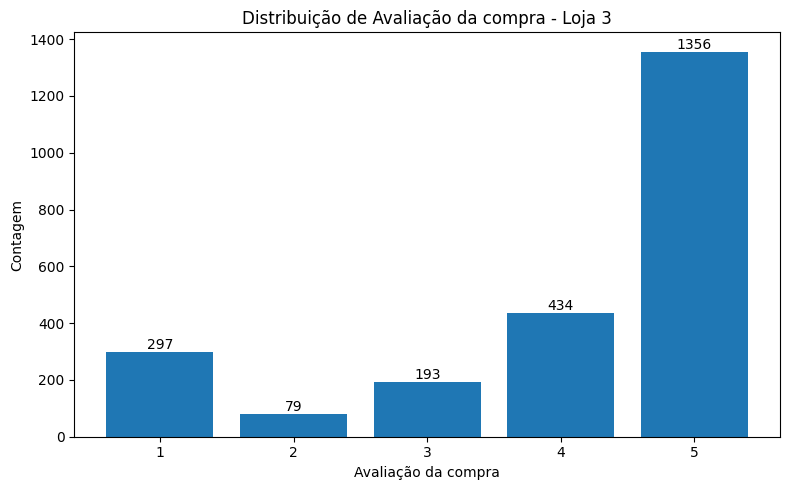

In [223]:
# Distribuição das Avaliações de Compra
grafico_distribuicao(df_loja, "Avaliação da compra", loja, False)

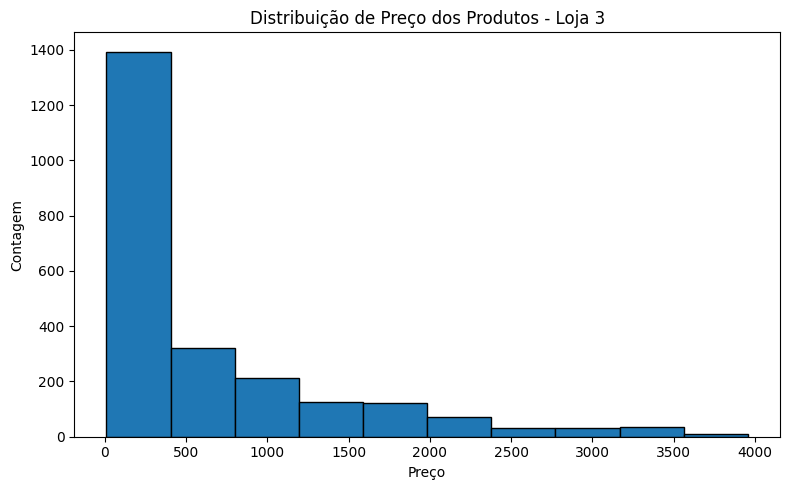

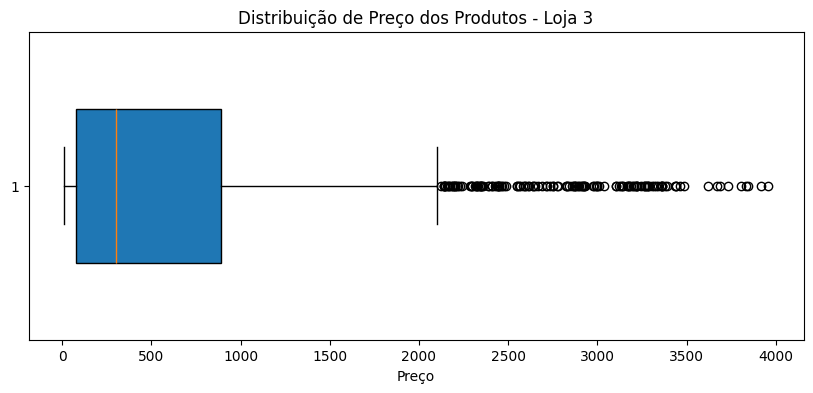

In [224]:
# Distribuição dos Preços dos Produtos 
grafico_histograma_numerico(df_loja, "Preço", loja, 10)
grafico_boxplot_numerico(df_loja,"Preço", loja)

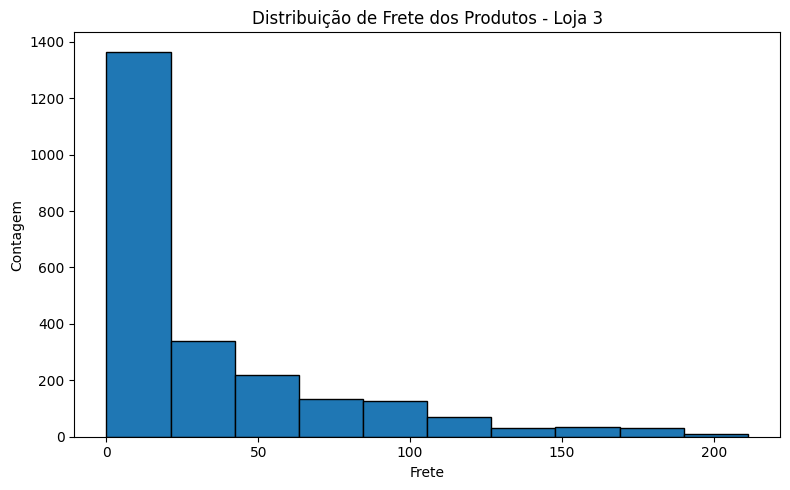

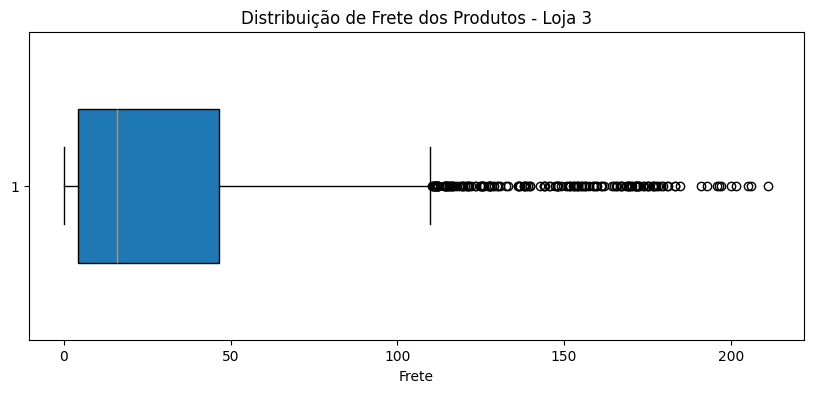

In [225]:
# Distribuição do Frete dos Produtos
grafico_histograma_numerico(df_loja, "Frete", loja, 10)
grafico_boxplot_numerico(df_loja,"Frete", loja)

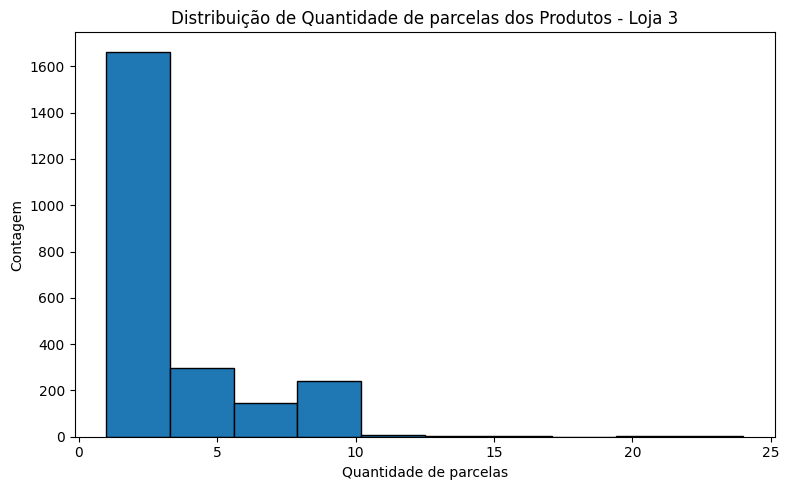

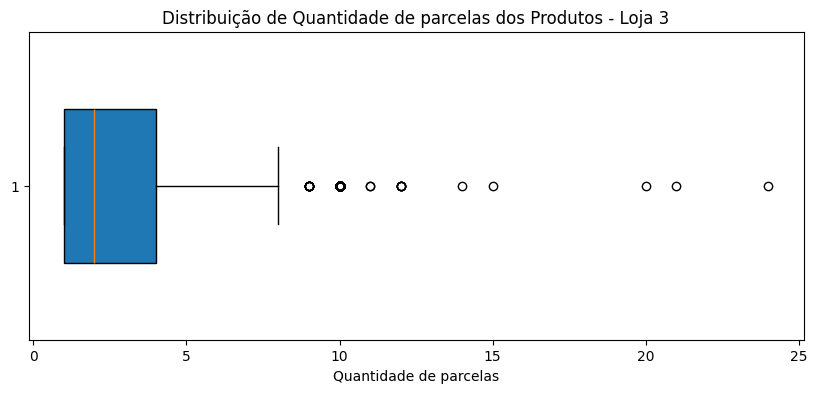

In [226]:
# Distribuição da Quantidade de parcelas dos Produtos
grafico_histograma_numerico(df_loja, "Quantidade de parcelas", loja, 10)
grafico_boxplot_numerico(df_loja,"Quantidade de parcelas", loja)

#### Loja 4

In [227]:
# Atualizar loja
loja = "Loja 4"
df_loja = loja4

##### Conhecendo os dados

In [228]:
conhecendo_dados(df_loja, loja)

=== Loja 4 ===


(2358, 12)

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Lava louças,eletrodomesticos,1446.46,74.604083,11/11/2022,Rafael Costa,SP,4,cartao_credito,3,-22.19,-48.79
1,Cama box,moveis,631.70,33.919251,03/01/2020,Thiago Silva,GO,5,cartao_credito,2,-15.98,-49.86
2,Bola de basquete,esporte e lazer,31.54,0.000000,25/12/2022,Larissa Alves,MG,5,boleto,1,-18.10,-44.38
3,Modelagem preditiva,livros,76.93,1.680730,23/11/2021,Lucas Oliveira,MG,3,boleto,1,-18.10,-44.38
4,Fone de ouvido,eletronicos,185.14,7.442587,25/04/2022,Bianca Santos,SP,4,cartao_credito,7,-22.19,-48.79


##### Qualidade dos Dados

Os dados foram disponibilizados sem valores nulos, sem duplicidade, sem valores negativos ou zerados

In [229]:
# Verificar tipos, estrutura e se há nulos
df_loja.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2358 entries, 0 to 2357
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Produto                 2358 non-null   object 
 1   Categoria do Produto    2358 non-null   object 
 2   Preço                   2358 non-null   float64
 3   Frete                   2358 non-null   float64
 4   Data da Compra          2358 non-null   object 
 5   Vendedor                2358 non-null   object 
 6   Local da compra         2358 non-null   object 
 7   Avaliação da compra     2358 non-null   int64  
 8   Tipo de pagamento       2358 non-null   object 
 9   Quantidade de parcelas  2358 non-null   int64  
 10  lat                     2358 non-null   float64
 11  lon                     2358 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.2+ KB


In [230]:
# Validação se há alguma data incorreta - Considerando que o campo esta como object 
datas_convertidas = pd.to_datetime(df_loja["Data da Compra"], dayfirst=True, errors="coerce")
quantidade_invalidas = datas_convertidas.isna().sum()

print(f"Data da Compra: {quantidade_invalidas} valores incorretos")

Data da Compra: 0 valores incorretos


##### Explorando os Dados

In [231]:
# Estatísticas decritivas das vendas
estatisticas_loja(df_loja, loja)


 Loja 4 - Colunas Numéricas 


,Preço,Frete,Avaliação da compra,Quantidade de parcelas,lat,lon
count,2358.000000,2358.000000,2358.000000,2358.000000,2358.000000,2358.000000
mean,587.149101,31.278997,3.995759,2.896098,-20.494215,-47.107553
std,758.341290,40.373136,1.403063,2.730393,5.433033,4.159156
min,10.170000,0.000000,1.000000,1.000000,-30.170000,-65.100000
25%,71.225000,3.847061,3.000000,1.000000,-22.250000,-48.790000
50%,279.315000,14.614197,5.000000,1.000000,-22.190000,-48.790000
75%,845.577500,44.438533,5.000000,4.000000,-18.100000,-44.380000
max,3869.560000,206.325555,5.000000,18.000000,1.410000,-36.590000



 Loja 4 - Colunas Categóricas 


,Produto,Categoria do Produto,Data da Compra,Vendedor,Local da compra,Tipo de pagamento
count,2358,2358,2358,2358,2358,2358
unique,51,8,1030,14,25,4
top,Cama box,moveis,13/11/2020,Felipe Santos,SP,cartao_credito
freq,62,480,9,196,991,1720


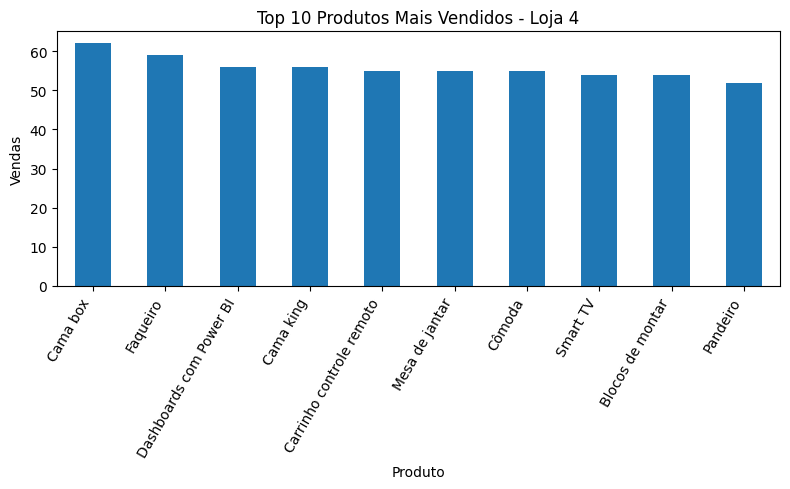

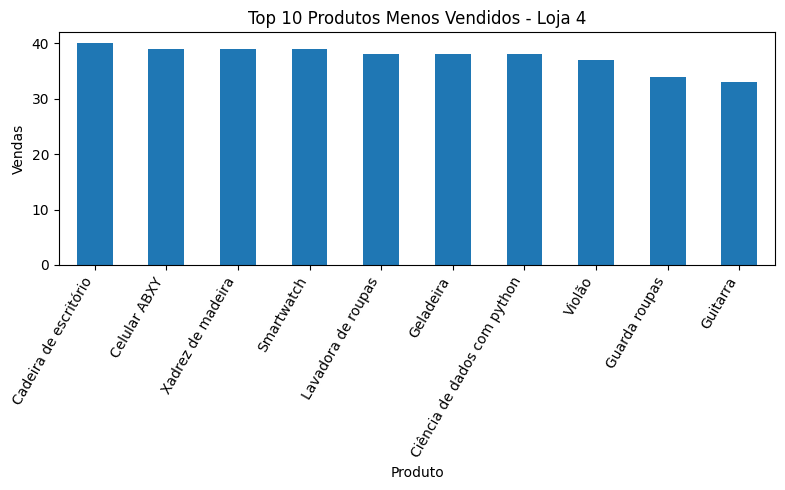

In [232]:
# Top 10 produtos mais vendidos e menos vendidos
grafico_top_categorias(df_loja, "Produto", loja, 10)
grafico_top_categorias(df_loja, "Produto", loja, 10, False)

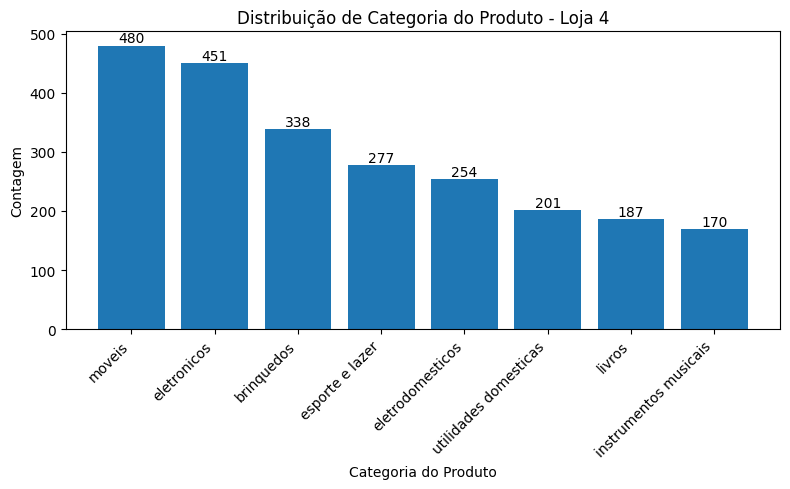

In [233]:
# Distribuição das Categorias do Produto 
grafico_distribuicao(df_loja,"Categoria do Produto", loja)

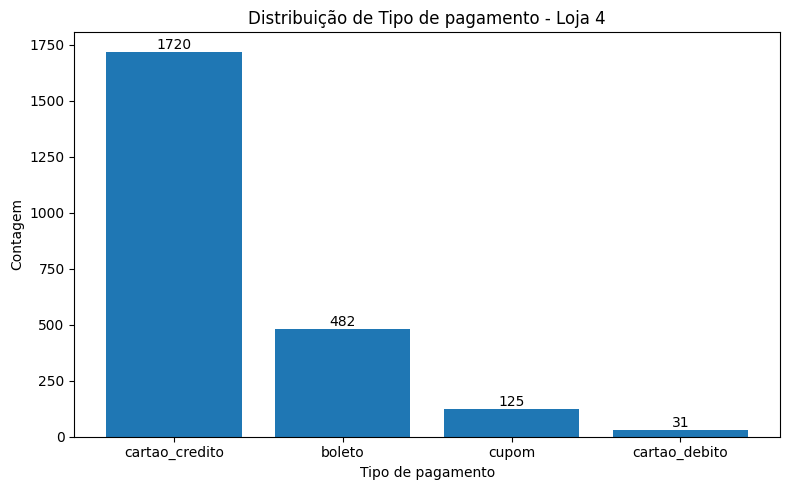

In [234]:
# Distribuição dos Tipos de Pagamento
grafico_distribuicao(df_loja,"Tipo de pagamento", loja, False)

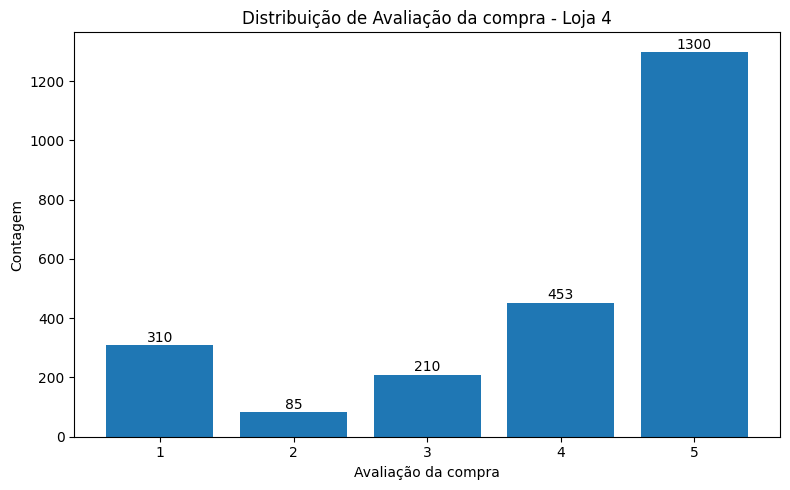

In [235]:
# Distribuição das Avaliações de Compra
grafico_distribuicao(df_loja, "Avaliação da compra", loja, False)

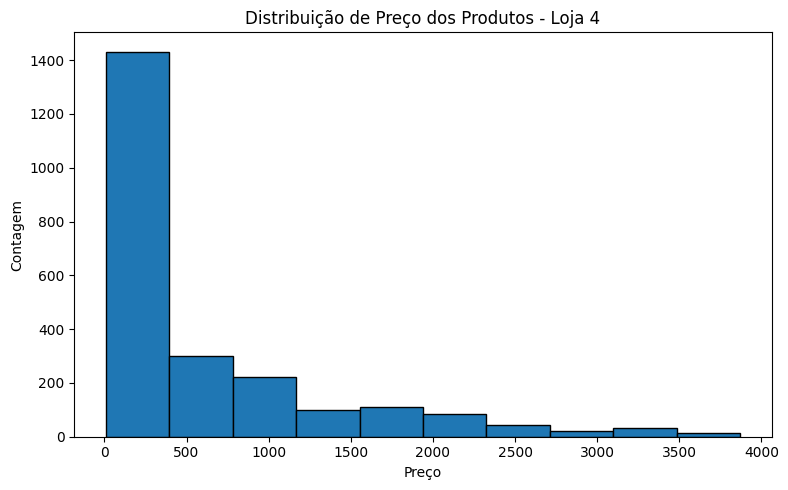

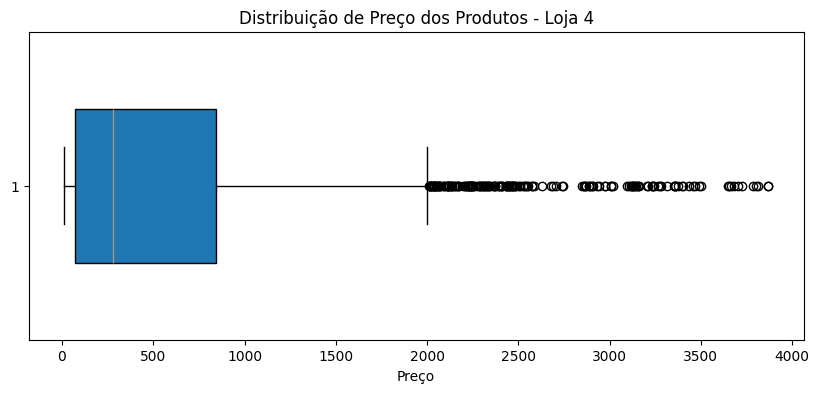

In [236]:
# Distribuição dos Preços dos Produtos 
grafico_histograma_numerico(df_loja, "Preço", loja, 10)
grafico_boxplot_numerico(df_loja,"Preço", loja)


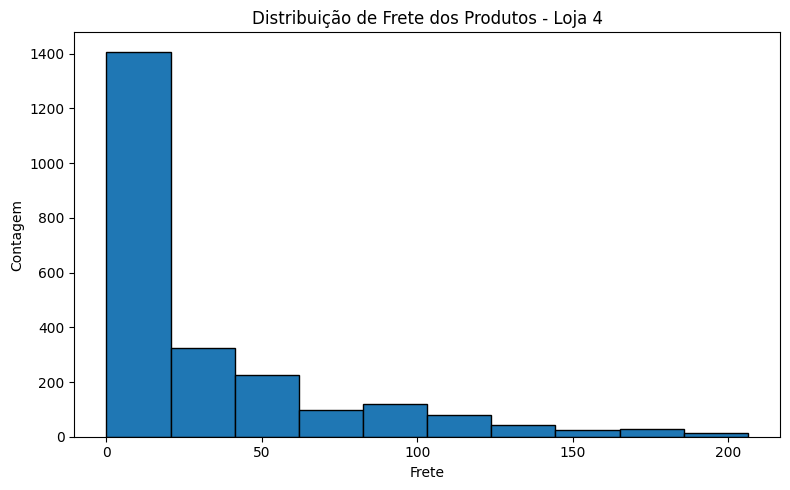

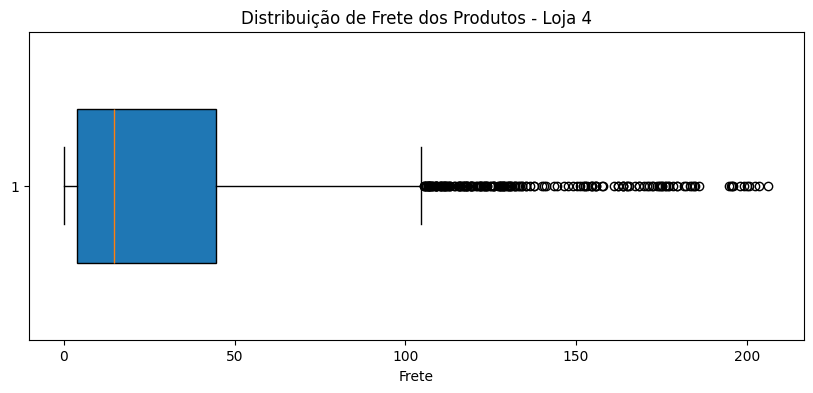

In [237]:
# Distribuição do Frete dos Produtos
grafico_histograma_numerico(df_loja, "Frete", loja, 10)
grafico_boxplot_numerico(df_loja,"Frete", loja)

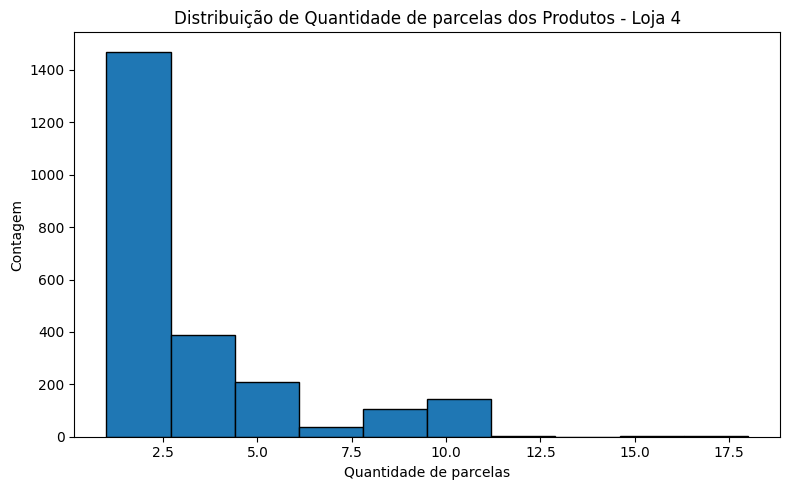

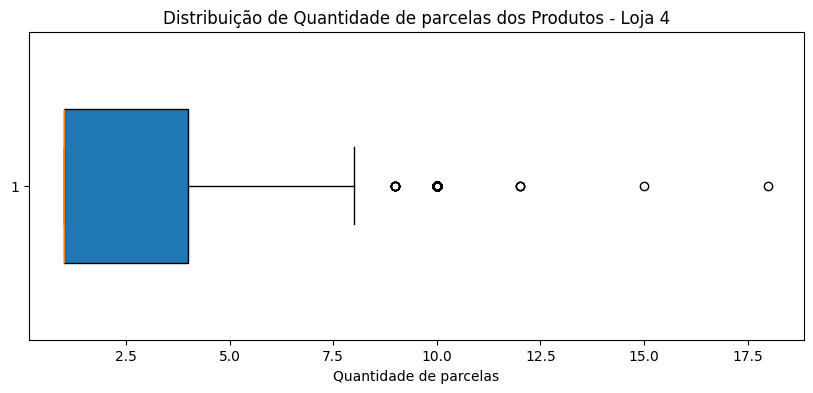

In [238]:
# Distribuição da Quantidade de parcelas dos Produtos
grafico_histograma_numerico(df_loja, "Quantidade de parcelas", loja, 10)
grafico_boxplot_numerico(df_loja,"Quantidade de parcelas", loja)

### Resumo da Análise Exploratória

Os dados analisados contêm registros de vendas de quatro lojas da rede Alura Store.

#### 1. Estrutura e Volume de Dados

* Todas as lojas possuem 2.359 registros, exceto a Loja 4 com 2.358 registros.
* Não há valores nulos em nenhuma coluna, garantindo consistência na análise.
* Todas as lojas possuem 12 colunas: 
  * 6 numéricas (Preço, Frete, Avaliação da compra, Quantidade de parcelas, lat, lon) 
  * 6 categóricas (Produto, Categoria do Produto, Data da Compra, Vendedor, Local, Tipo de pagamento).

#### 2. Produtos e Categorias

* Cada loja possui: 
  * 51 produtos distintos distribuídos em categorias 
  * 8 categorias: brinquedos, eletrodomesticos, eletronicos, esporte e lazer, instrumentos musicais, livros, moveis e utilidades domesticas 
  
* Produto mais frequente por loja:

  * Loja 1: Micro-ondas
  * Loja 2: Iniciando em programação
  * Loja 3: Kit banquetas
  * Loja 4: Cama box

* Categoria mais comum em todas as lojas: 

  * moveis: indicando foco em produtos para casa.

* Produtos mais comuns em todas as lojas: 
  * Lojas 1 e 2 têm 4 produtos mais vendidos em comum (Micro-ondas, Copo térmico, Bloco de montar, Jogo de panelas), sugerindo perfil de clientes semelhante.
  * Loja 3 compartilha apenas 2 produtos mais vendidos com as Lojas 1 e 2 (Cômoda, Jogo de panelas), indicando público com preferências distintas.
  * Loja 4 compartilha 7 produtos do seu top 10 com outras lojas, sendo 5 deles com a Loja 3 (Cama King, Carrinho Controle Remoto, Mesa Jantar, Comoda, SmartTV), indicando maior proximidade no perfil de vendas entre essas duas lojas.  

* Produtos menos vendidos em comum em todas as lojas: 
  * A Loja 3 apresenta 3 dos produtos menos vendidos (Copo térmico, Micro-ondas e Bloco de montar) que estão na lista dos produtos mais vendidos da Loja 1, reforçando a sugestão do perfil distinto de clientes.
  * A Loja 4 apresenta somente 2 produtos menos vendidos em comum com as demais lojas: Celular (Loja 1 e 2) e Guitarra (Loja 3), reforçando também a sugestão de perfil distinto de clientes com a Loja 1 e 2. 

#### 3. Preços e Frete

* Média de preço: varia de 587 a 650, sendo a Loja 1 a que apresentou o maior valor médio de preço dos produtos vendidos, enquanto a Loja 4 apresentou o menor.
* Média de frete: entre 31 e 35, sem grandes diferenças entre lojas.
* Há registros de compras com frete igual a zero, o que pode indicar promoções ou políticas de frete grátis dependendo do valor do produto. 
* Produtos de maior valor: até ≈3.900 em todas as lojas
* Produtos de menor valor: entre 10 a 11 em todas as lojas.
* A maior parte dos produtos vendidos apresenta preços e fretes acima da mediana, com alguns outliers representando preços acima de ≈2000 e fretes acima de ≈100.

#### 4. Avaliações e Satisfação

* As Avaliações médias variam de 3,97 a 4,05, indicando satisfação geral relativamente alta.
* Todas as lojas apresentam avaliações de nota 1, o que poderia ser investigado futuramente para entender os casos de insatisfação.
* As Lojas 1 e 4 possuem desvio um pouco maior, mostrando mais variabilidade na experiência do cliente.

#### 5. Tipo de Pagamento e Parcelamento

* Forma de pagamento mais comum: cartão de crédito em todas as lojas.
* Quantidade de parcelas: geralmente 1 a 4 parcelas, com alguns casos extremos chegando até 24 na Loja 1.
* Isso indica que as lojas atendem tanto pagamentos à vista quanto parcelados, mas a maioria prefere parcelar em poucas vezes.

#### 6. Localização Geográfica

* As lojas atendem clientes em diversos estados brasileiros, porém a maior concentração de vendas ocorre em SP.
* Latitude e longitude não foram analisados, mas podem ser úteis para análises geográficas futuras, como identificar regiões com maior volume de vendas ou padrão de comportamento de clientes por localidade.

### Análise de Dados

#### Preparando os Dados

In [239]:
# Unindo os dataframes 
loja1["Loja"] = "Loja 1"
loja2["Loja"] = "Loja 2"
loja3["Loja"] = "Loja 3"
loja4["Loja"] = "Loja 4"

df = pd.concat([loja1, loja2, loja3, loja4], ignore_index=True)

df.head(1)

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon,Loja
0,Assistente virtual,eletronicos,219.08,9.24979,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,Loja 1


#### Faturamento das Lojas

In [240]:
# Faturamento Total de Cada Loja
faturamento_lojas = df.groupby("Loja")["Preço"].sum().sort_values(ascending=False)
faturamento_lojas

Loja
Loja 1    1534509.12
Loja 2    1488459.06
Loja 3    1464025.03
Loja 4    1384497.58
Name: Preço, dtype: float64

#### Vendas por Categoria

In [241]:
# Vendas por Categoria - Ordenadas 
vendas_categoria = pd.crosstab(df["Categoria do Produto"], df["Loja"])
vendas_categoria = vendas_categoria.loc[vendas_categoria.sum(axis=1).sort_values(ascending=False).index]

print(vendas_categoria)

Loja                   Loja 1  Loja 2  Loja 3  Loja 4
Categoria do Produto                                 
moveis                    465     442     499     480
eletronicos               448     422     451     451
brinquedos                324     313     315     338
eletrodomesticos          312     305     278     254
esporte e lazer           284     275     277     277
instrumentos musicais     182     224     177     170
livros                    173     197     185     187
utilidades domesticas     171     181     177     201


In [242]:
# Total Faturamento de Vendas por Categoria 
faturamento_categoria_loja = pd.pivot_table(
    df,
    index="Categoria do Produto",
    columns="Loja",
    values="Preço",
    aggfunc="sum",
    fill_value=0
)

# Adiciona coluna com total geral por categoria e ordena
faturamento_categoria_loja["Total"] = faturamento_categoria_loja.sum(axis=1)
faturamento_categoria_loja = faturamento_categoria_loja.sort_values(by="Total", ascending=False)

print(faturamento_categoria_loja)

Loja                      Loja 1     Loja 2     Loja 3     Loja 4       Total
Categoria do Produto                                                         
eletronicos            572659.23  547773.71  547699.92  545966.86  2214099.72
eletrodomesticos       484913.36  464758.13  438984.89  377680.65  1766337.03
moveis                 250178.11  235234.68  268095.56  256705.65  1010214.00
instrumentos musicais  121731.69  139987.03  103174.45  100136.50   465029.67
esporte e lazer         52387.55   46326.09   47456.10   44465.65   190635.39
brinquedos              23993.78   21262.21   25869.20   27015.67    98140.86
utilidades domesticas   16931.48   19662.86   20080.21   20098.83    76773.38
livros                  11713.92   13454.35   12664.70   12427.77    50260.74


#### Média de Avaliação de Compra

In [243]:
# Média das Avaliações de Compra por Loja
media_avaliacao = df.groupby("Loja")["Avaliação da compra"].mean().round(3)
media_avaliacao

Loja
Loja 1    3.977
Loja 2    4.037
Loja 3    4.048
Loja 4    3.996
Name: Avaliação da compra, dtype: float64

#### Produtos Mais e Menos Vendidos

In [244]:
# Produtos Mais e Menos Vendidos por Loja
for nome in df["Loja"].unique():
    
    df_loja = df[df["Loja"] == nome]  
    
    vendas = df_loja["Produto"].value_counts()
    
    mais = vendas.head(5).reset_index()
    mais.columns = ["Produto + vendido", "Vendas"]
    
    menos = vendas.tail(5).reset_index()
    menos.columns = ["Produto - vendido", "Vendas"]
    
    espaco = pd.DataFrame({" ": [""]*5})
    
    tabela = pd.concat([mais, espaco, menos], axis=1)

    print(f"\n{nome}")
    display(tabela)


Loja 1


,Produto + vendido,Vendas,,Produto - vendido,Vendas
0,Micro-ondas,60,,Ciência de dados com python,39
1,TV Led UHD 4K,60,,Pandeiro,36
2,Guarda roupas,60,,Panela de pressão,35
3,Secadora de roupas,58,,Headset,33
4,Cômoda,56,,Celular ABXY,33



Loja 2


,Produto + vendido,Vendas,,Produto - vendido,Vendas
0,Iniciando em programação,65,,Fone de ouvido,37
1,Micro-ondas,62,,Poltrona,35
2,Bateria,61,,Mesa de jantar,34
3,Violão,58,,Impressora,34
4,Pandeiro,58,,Jogo de tabuleiro,32



Loja 3


,Produto + vendido,Vendas,,Produto - vendido,Vendas
0,Kit banquetas,57,,Guitarra,38
1,Mesa de jantar,56,,Jogo de copos,36
2,Cama king,56,,Mochila,36
3,Jogo de panelas,55,,Micro-ondas,36
4,Cômoda,55,,Blocos de montar,35



Loja 4


,Produto + vendido,Vendas,,Produto - vendido,Vendas
0,Cama box,62,,Geladeira,38
1,Faqueiro,59,,Ciência de dados com python,38
2,Dashboards com Power BI,56,,Violão,37
3,Cama king,56,,Guarda roupas,34
4,Carrinho controle remoto,55,,Guitarra,33


In [245]:
# Top 5 dos produtos com maior faturamento (independente da Loja)
maior_top5_produtos = df.groupby("Produto")["Preço"].sum().sort_values(ascending=False).head(5)
maior_top5_produtos

Produto
TV Led UHD 4K         576652.70
Celular Plus X42      534735.14
Geladeira             513249.34
Smart TV              386963.12
Lavadora de roupas    323292.37
Name: Preço, dtype: float64

In [246]:
# Top 5 dos produtos de menor faturamento (independente da Loja)
menor_top5_produtos = df.groupby("Produto")["Preço"].sum().sort_values(ascending=False).tail(5)
menor_top5_produtos

Produto
Jogo de copos        7445.28
Xadrez de madeira    6865.90
Dinossauro Rex       4150.53
Corda de pular       4090.93
Cubo mágico 8x8      3638.68
Name: Preço, dtype: float64

#### Frete Médio por Loja

In [247]:
# Frete Médio por Loja
frete_medio = df.groupby("Loja")["Frete"].mean().round(3)
frete_medio

Loja
Loja 1    34.692
Loja 2    33.622
Loja 3    33.074
Loja 4    31.279
Name: Frete, dtype: float64

#### Gerando Gráficos

##### Visualizações sobre Faturamento das Lojas

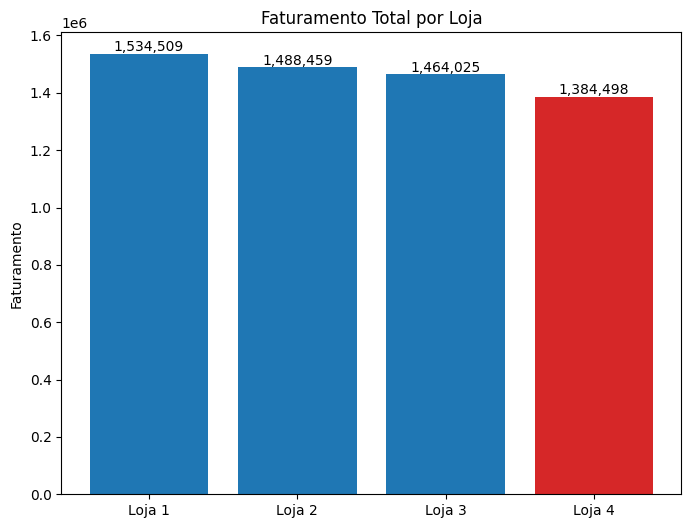

In [248]:
# Faturamento das Lojas em todo período 

# Determina a cor de cada barra
min_fat = faturamento_lojas.min()
cores = ["#d62728" if val == min_fat else "#1f77b4" for val in faturamento_lojas]

# Cria o gráfico
fig, ax = plt.subplots(figsize=(8,6))
bars = ax.bar(faturamento_lojas.index, faturamento_lojas.values, color=cores)

ax.set_title("Faturamento Total por Loja")
ax.set_ylabel("Faturamento")

# Mostra os valores acima das barras
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom'
    )

plt.show()

In [249]:
# Garante que a coluna 'Data da Compra' é datetime
df["Data da Compra"] = pd.to_datetime(df["Data da Compra"], dayfirst=True)

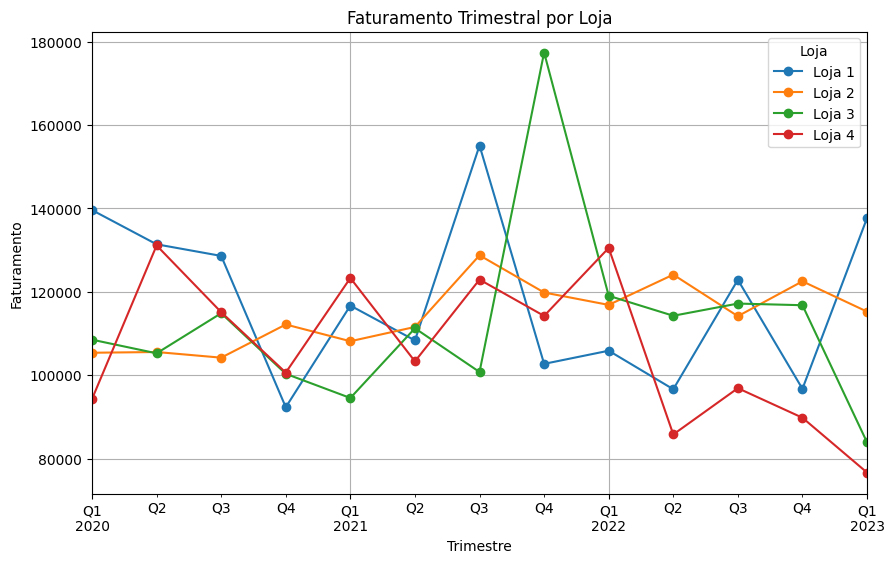

In [250]:
# Faturamento das Lojas em todo período por Trimestre 

# Extrai ano e trimestre
df["Trimestre"] = df["Data da Compra"].dt.to_period("Q")

# Agrupa por trimestre e loja, somando o faturamento
faturamento_trimestral = df.groupby(["Trimestre", "Loja"])["Preço"].sum().unstack()

faturamento_trimestral.plot(marker='o', figsize=(10,6))
plt.title("Faturamento Trimestral por Loja")
plt.ylabel("Faturamento")
plt.xlabel("Trimestre")
plt.grid(True)
plt.legend(title="Loja")
plt.show()

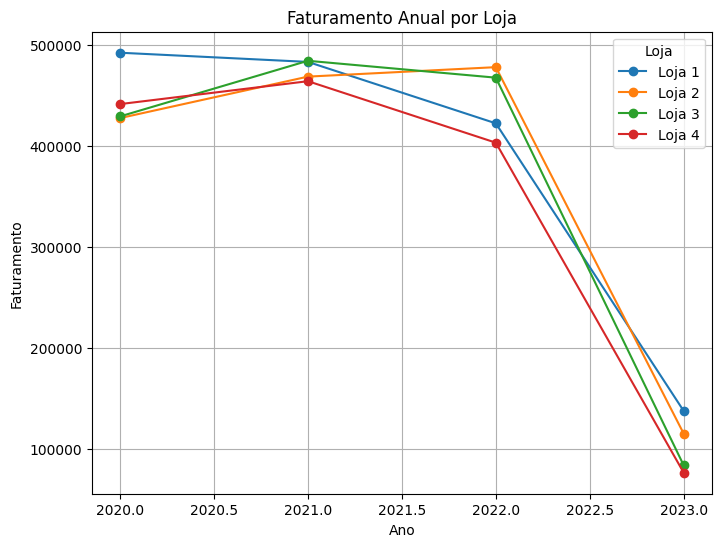

In [251]:
# Faturamento das lojas por Ano

# Extrai o ano da compra
df["Ano"] = df["Data da Compra"].dt.year

# Agrupa por ano e loja, somando o faturamento
faturamento_anual = df.groupby(["Ano", "Loja"])["Preço"].sum().unstack()

faturamento_anual.plot(marker='o', figsize=(8,6))
plt.title("Faturamento Anual por Loja")
plt.ylabel("Faturamento")
plt.xlabel("Ano")
plt.grid(True)
plt.legend(title="Loja")
plt.show()

##### Visualizações sobre Faturamento por Categorias

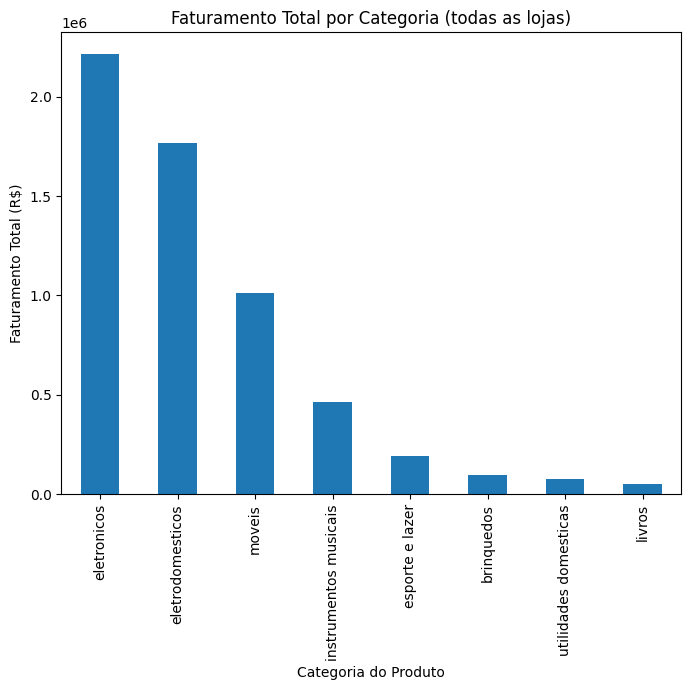

In [261]:
# Faturamento Total por Categoria
faturamento_categoria_loja_total = faturamento_categoria_loja["Total"].sort_values(ascending=False)

plt.figure(figsize=(8,6))
faturamento_categoria_loja_total.plot(
    kind="bar"
)

plt.title("Faturamento Total por Categoria (todas as lojas)")
plt.xlabel("Categoria do Produto")
plt.ylabel("Faturamento Total (R$)")
plt.xticks(rotation=90)
plt.show()

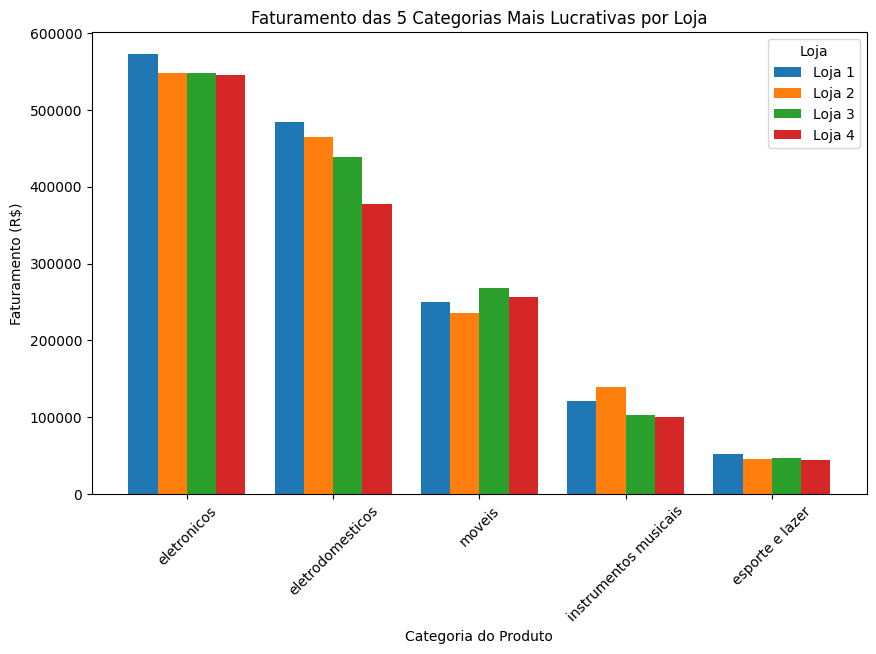

In [262]:
# Top 5 categorias pelo faturamento total
top5_categorias = faturamento_categoria_loja["Total"].sort_values(ascending=False).head(5).index

faturamento_top5 = faturamento_categoria_loja.loc[top5_categorias, ["Loja 1", "Loja 2", "Loja 3", "Loja 4"]]

faturamento_top5.plot(
    kind="bar",
    figsize=(10,6),
    width=0.8
)

plt.title("Faturamento das 5 Categorias Mais Lucrativas por Loja")
plt.xlabel("Categoria do Produto")
plt.ylabel("Faturamento (R$)")
plt.xticks(rotation=45)
plt.legend(title="Loja")
plt.show()

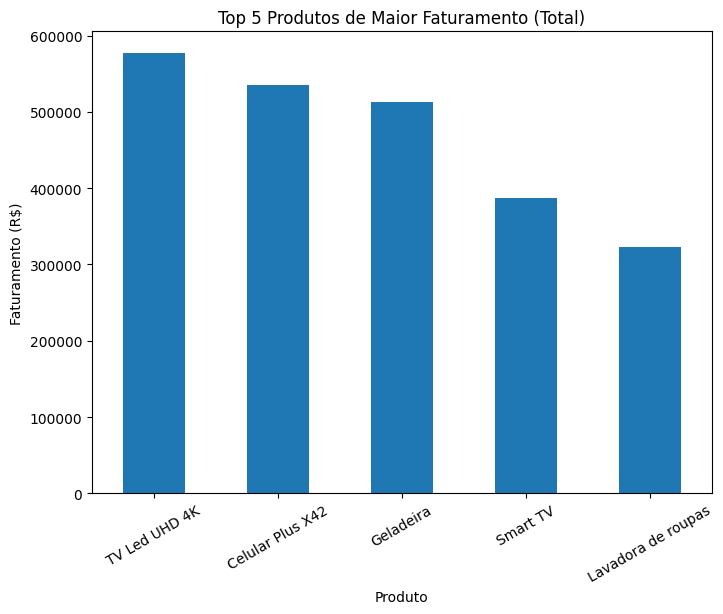

In [254]:
# Top 5 produtos de maior faturamento (independente da loja)

plt.figure(figsize=(8,6))
maior_top5_produtos.plot(kind="bar") 
plt.title("Top 5 Produtos de Maior Faturamento (Total)")
plt.ylabel("Faturamento (R$)")
plt.xlabel("Produto")
plt.xticks(rotation=30)
plt.show()

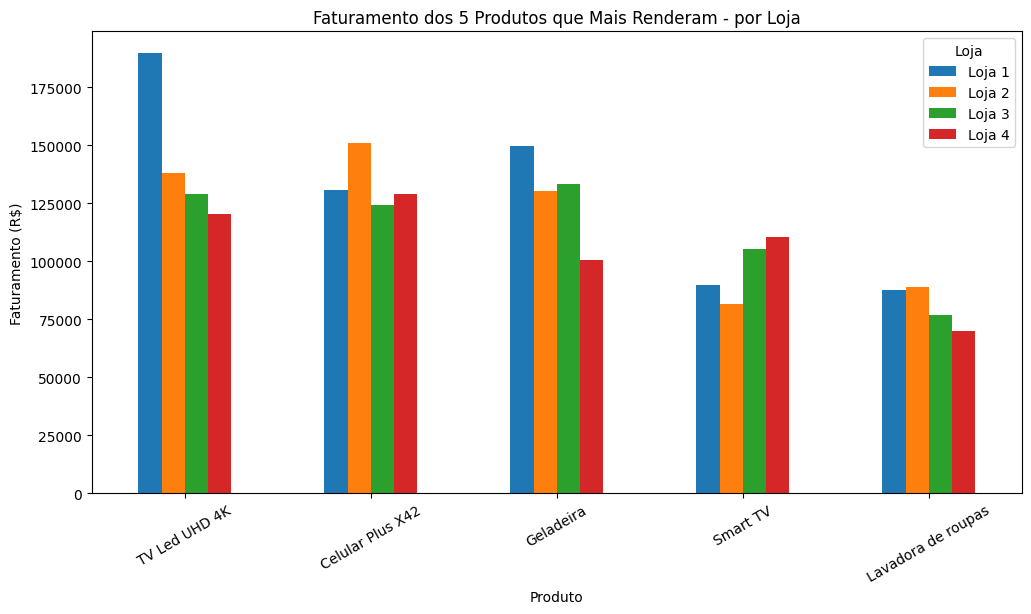

In [255]:
# Faturamento dos 5 Produtos Mais Vendidos - Visualização por loja  
# Filtra o df apenas pelos produtos do top5 existente
df_top5 = df[df["Produto"].isin(maior_top5_produtos.index)]  

# Pivot table: faturamento por produto e loja
faturamento_top5_loja = df_top5.pivot_table(
    index="Produto",
    columns="Loja",
    values="Preço",
    aggfunc="sum",
    fill_value=0
)

# Mantém a ordem do top5 original
faturamento_top5_loja = faturamento_top5_loja.loc[maior_top5_produtos.index]
ax = faturamento_top5_loja.plot(kind="bar", figsize=(12,6))  

plt.title("Faturamento dos 5 Produtos que Mais Renderam - por Loja")
plt.ylabel("Faturamento (R$)")
plt.xlabel("Produto")
plt.xticks(rotation=30)
plt.legend(title="Loja")
plt.show()

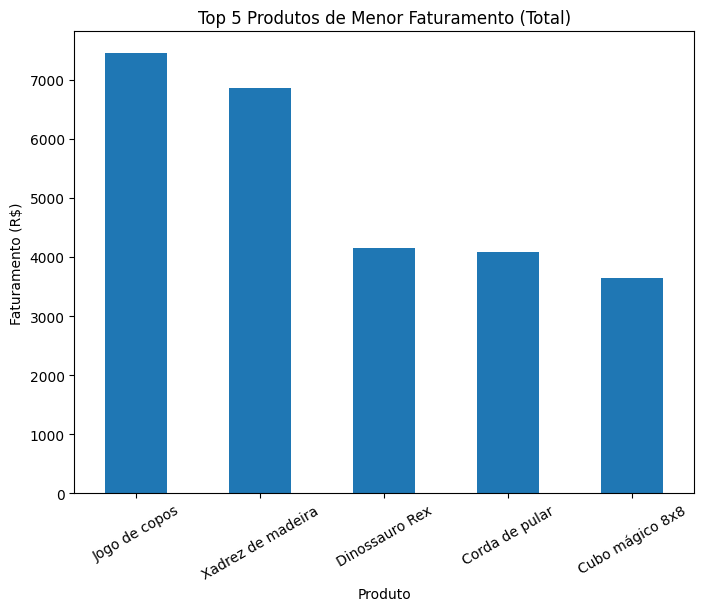

In [256]:
# Top 5 produtos de menor faturamento (independente da loja)
plt.figure(figsize=(8,6))
menor_top5_produtos.plot(kind="bar") 
plt.title("Top 5 Produtos de Menor Faturamento (Total)")
plt.ylabel("Faturamento (R$)")
plt.xlabel("Produto")
plt.xticks(rotation=30)
plt.show()

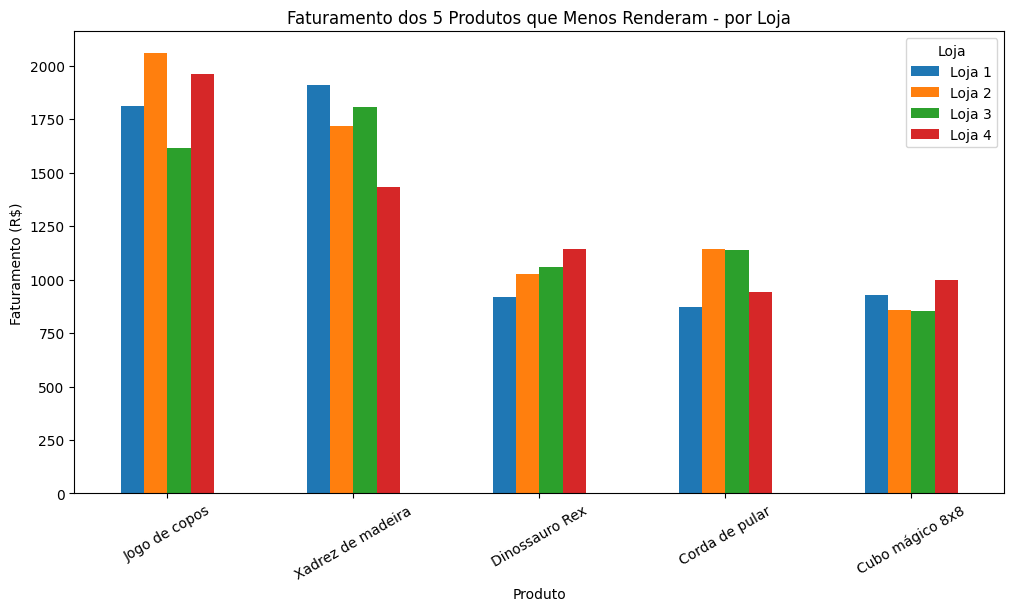

In [257]:
# Faturamento dos 5 Produtos Menos Vendidos - Visualização por loja  
# Filtra o df apenas pelos produtos do top5 existente
df_top5 = df[df["Produto"].isin(menor_top5_produtos.index)]  

# Pivot table: faturamento por produto e loja
faturamento_top5_loja = df_top5.pivot_table(
    index="Produto",
    columns="Loja",
    values="Preço",
    aggfunc="sum",
    fill_value=0
)

# Mantém a ordem do top5 original
faturamento_top5_loja = faturamento_top5_loja.loc[menor_top5_produtos.index]

ax = faturamento_top5_loja.plot(kind="bar", figsize=(12,6))  
plt.title("Faturamento dos 5 Produtos que Menos Renderam - por Loja")
plt.ylabel("Faturamento (R$)")
plt.xlabel("Produto")
plt.xticks(rotation=30)
plt.legend(title="Loja")
plt.show()

##### Visualizações sobre Relação entre Preço e Avaliação de Compra 

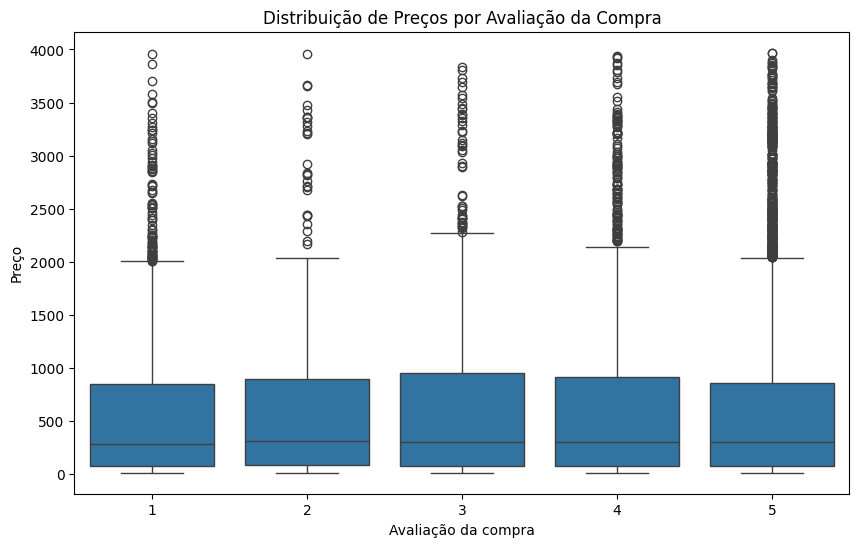

In [263]:
# Relação do Preço do Produto com a Avaliação da Compra 
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Avaliação da compra",
    y="Preço")

plt.title("Distribuição de Preços por Avaliação da Compra")
plt.xlabel("Avaliação da compra")
plt.ylabel("Preço")

plt.show()

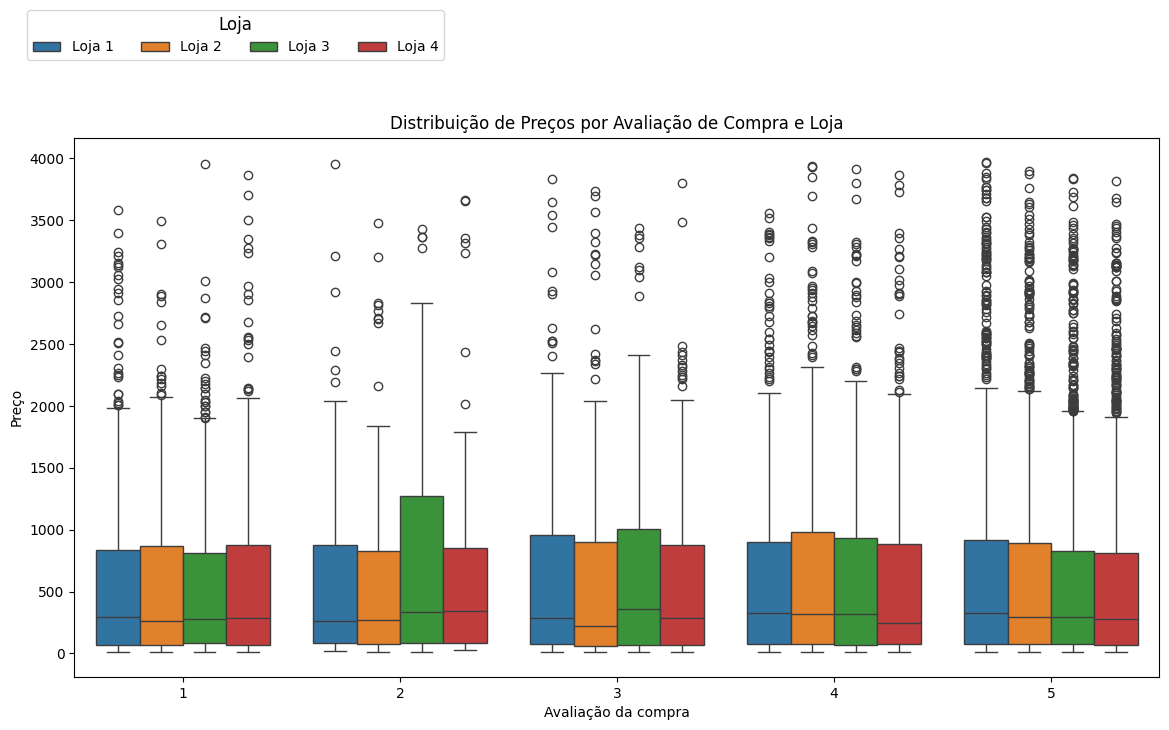

In [264]:
# Preço por Avaliação de Compra por Loja
plt.figure(figsize=(14,7))  

sns.boxplot(
    data=df,
    x="Avaliação da compra",
    y="Preço",
    hue="Loja"
)

plt.title("Distribuição de Preços por Avaliação de Compra e Loja")
plt.xlabel("Avaliação da compra")
plt.ylabel("Preço")

# Legenda 
plt.legend(
    title="Loja",
    fontsize=10,
    title_fontsize=12,
    loc='upper left',
    bbox_to_anchor=(-0.05, 1.25),  
    ncol=len(df['Loja'].unique())
)

plt.show()

## **Relatório Final – Análise das Lojas da Alura Store**

### **Introdução**

O objetivo desta análise foi avaliar o desempenho das quatro lojas da rede Alura Store para auxiliar o Sr. João na decisão sobre qual delas seria mais adequada para venda. Para isso, foram analisados diversos indicadores de desempenho, incluindo o faturamento total das lojas, o faturamento por categoria de produtos, os produtos mais e menos vendidos, a média das avaliações dos clientes e o frete médio de cada loja. Além disso, gráficos foram utilizados para facilitar a visualização e comparação entre as lojas.


### **Análise das Lojas**

A análise do faturamento total mostra que a Loja 1 apresenta o maior faturamento, seguida pelas Lojas 2 e 3, enquanto a Loja 4 apresenta o menor faturamento entre as quatro lojas. Essa diferença indica que a Loja 4 tem menor contribuição para a receita total da rede.

Ao analisar o faturamento por categoria de produtos, observa-se que Eletrônicos é a categoria mais rentável, seguida por Eletrodomésticos e Móveis. Essas categorias concentram a maior parte da receita gerada pelas lojas. Apesar disso, a Loja 4 não se destaca de forma significativa nessas categorias em comparação com as demais lojas, mantendo um desempenho inferior ou semelhante, mas sem liderança em faturamento.

A análise dos produtos com maior faturamento reforça esse padrão. Produtos como TV Led UHD 4K, Celular Plus X42, Geladeira, Smart TV e Lavadora de roupas são os que mais geram receita no conjunto das lojas. No entanto, a Loja 4 não se destaca de forma relevante na venda desses produtos em comparação com as demais lojas. Nesse contexto, a Loja 4 somente teve o maior faturamento com o produto Smart TV, que é o 4º mais vendido. 

Por outro lado, a análise dos produtos de menor faturamento, como Cubo mágico 8x8, Corda de pular e Dinossauro Rex, mostra que esses itens têm impacto muito pequeno na receita total, servindo apenas como complemento ao portfólio de produtos. Além disso, as Loja 4 e 3 se destacam nas vendas desses produtos. 

Em relação à avaliação média dos clientes, todas as lojas apresentam resultados semelhantes, com médias próximas de 4 pontos. A Loja 3 possui a melhor média de avaliação, seguida pelas Lojas 2 e 4, enquanto a Loja 1 apresenta a menor média. Ainda assim, as diferenças são pequenas, indicando um nível geral de satisfação semelhante entre as lojas.

Considerando a relação entre o preço dos produtos e as avaliações dos clientes, observada no gráfico de distribuição de preço por avaliação (boxplot), percebe-se que produtos com diferentes faixas de preço recebem avaliações variadas. Existem casos de produtos com preços elevados que ainda apresentam boas avaliações, indicando que os clientes percebem valor nesses produtos. Ao mesmo tempo, alguns produtos apresentam avaliações mais baixas independentemente do preço, sugerindo que fatores como qualidade, expectativa do cliente ou experiência de compra também influenciam na satisfação.

A análise do frete médio por loja mostra que a Loja 4 possui o menor custo médio de frete, o que poderia representar uma vantagem competitiva. No entanto, mesmo com frete mais baixo, essa loja não apresenta melhor desempenho em faturamento ou vendas.

Os gráficos gerados durante a análise ajudam a visualizar esses padrões. O gráfico de faturamento total por loja evidencia a posição inferior da Loja 4 em relação às demais. Já os gráficos de faturamento por categoria mostram que as categorias mais rentáveis são dominadas principalmente pelas outras lojas. Além disso, as visualizações também ajudam a identificar como os produtos mais lucrativos estão distribuídos entre as lojas.


### **Conclusão**

Com base em todos os indicadores analisados a Loja 4 se destaca como a unidade com menor desempenho geral.

Apesar de apresentar um frete médio mais baixo e avaliações de clientes semelhantes às demais lojas, esses fatores não compensam seu menor faturamento total e menor destaque nas categorias e produtos que geram mais receita.

Dessa forma, considerando o impacto financeiro e o desempenho comparativo entre as lojas, a Loja 4 é a mais indicada para ser vendida, pois sua retirada teria o menor impacto na receita geral da rede e permitiria ao Sr. João concentrar esforços nas lojas com melhor desempenho.